# Clean and join `emr_oocyte` and `emr_oocyte_day`

A first-pass cleaning and joining of the oocyte tables before analysis.

What this notebook does, in order:
1. **Profile** every column (how full it is, how many distinct values, its type)
2. **Drop** columns that are completely empty
3. **Review** columns that hold only a single value
4. **Merge** the oocyte dataframes (by absolute_oocyteid)
5. **Tidy** column types
6. **Save** a cleaned copy + keep an audit note of what changed

The same `profile()` function works on the other `emr_*` tables too, so you can reuse this pattern.

> **Before running:** finish the venv setup in this repo and install the packages — open a terminal and run `pip install pandas pyarrow`. The `requirements.txt` alongside this notebook lists everything.
>
> **Important:** keep your raw patient data in a `data/` folder that is git-ignored. Don't commit EMR exports to GitHub, even a private repo.

## Setup

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import import_ipynb

import helper_functions

In [217]:
# --- emr_oocyte ---
oocyte_PATH = Path("../data/emr_oocyte.csv")

# loading data
oocyte_df = pd.read_csv(oocyte_PATH)

# --- emr_oocyte_day ---
oocyte_day_PATH = Path("../data/emr_oocyte_day.csv")

# loading data
oocyte_day_df = pd.read_csv(oocyte_day_PATH)

C:\Users\tamar.schaap\AppData\Local\Temp\ipykernel_16200\4179078064.py:5: DtypeWarning: Columns (0: incubatortime) have mixed types. Specify dtype option on import or set low_memory=False.
  oocyte_df = pd.read_csv(oocyte_PATH)
C:\Users\tamar.schaap\AppData\Local\Temp\ipykernel_16200\4179078064.py:11: DtypeWarning: Columns (0: morphology, 1: uniform, 2: compaction, 3: aspherical, 4: granularcytoplasm, 5: vacuolisation, 6: ivm, 7: ah_note, 8: note, 9: cumulus, 10: fresh_donatedon, 11: pgd_performedby_other, 12: pgd_witness_other, 13: pgd_mosaic, 14: biopsy_accession_number, 15: biopsy_requisitionid, 16: pgd_karyotype, 17: pgd_mitosure, 18: pgtm_performed, 19: pgtm_technique, 20: pgtm_testmethod, 21: pgtm_indication, 22: pgtm_facility, 23: pgtm_numcells, 24: pgtm_ordered, 25: pgtm_inheritance, 26: pgtm_gene, 27: pgtm_partnervariant, 28: pgtsr_performed, 29: pgtsr_technique, 30: pgtsr_testmethod, 31: pgtsr_indication, 32: pgtsr_facility, 33: pgtsr_numcells, 34: pgtsr_ordered, 35: pgtsr_re

In [218]:
# list all columns of the oocyte_df
display(oocyte_df.columns)

Index(['id', 'addedby', 'addedon', 'deletedby', 'deletedon', 'patid',
       'donorid', 'cycleid', 'aspirationid', 'treatment',
       'treatment_performed', 'treatment_performedby', 'grouping', 'ord',
       'thawsampleid', 'semenanalysisid', 'incubator', 'incubatortime',
       'destroyed', 'cryopreserved', 'transferred', 'recipientid',
       'recipientcycleid', 'donate', 'carrierid', 'carriercycleid', 'max_day',
       'fresh_donor_oocyte_id', 'fresh_recipient_oocyte_id', 'oocyte_note',
       'icsi_tech', 'insemination_tech', 'original_ord', 'importid',
       'beforechanges_ord', 'absolute_oocyteid', 'eggsource_eligibility',
       'spermsource_eligibility', 'icsi_witness', 'chloe_well_id',
       'chloe_slide_id', 'chloe_well_external_id', 'picsi_performed'],
      dtype='str')

In [219]:
#display(oocyte_day_df.head(10))

In [220]:
# just notes to keep track of patients who's cycleid is not popping up
    # patid 226: they had an IVF cycle in may 2021 before nAble was used so that data is not accurate. Their FET cycle was in 2024 so the embryos are still in this dataset
    # patid 44627: they had donor eggs. one cycle was a ICSI with partner sperm, and 2 other cycles are FET cycles.
    # patid 87655: male same sexx couple with one donor oocyte thaw and ICSI and three FET cycles.
# patients below do not have that problem but looking to see if I can see which are euploid and aneuploid in the dataset
    # patid 27933: they had several IVF cycles and got a few embryos all together but the embryos did not undergo genetic testing so cannot see how many euploid and aneuploid
    # patid 136132: has 12 eggs from cycle and 6 blastocysts and 5 of them euploid and 1 aneuploid


In [285]:
## getting all rows from patid ___
#patid_23398_rows = oocyte_df[oocyte_df['patid'] == 23398]
#display(patid_23398_rows)

#patid_23398_rows_day = oocyte_day_df[oocyte_day_df['absolute_oocyteid'].isin(patid_23398_rows['absolute_oocyteid'])]
#display(patid_23398_rows_day.head(20))

#display(
#    patid_23398_rows_day[
#        patid_23398_rows_day["absolute_oocyteid"] == "794dbc9b-4522-45de-a047-f28372b47893"
#    ]
#)


# in oocyte_day_df, if absolute_oocyteid has multiple values of "grade"


In [222]:
## look up all rows with missing cycleid
#missing_cycleid_rows = oocyte_df[oocyte_df['cycleid'].isna()]
#display(missing_cycleid_rows.sample(30))

## look up all rows with absolute_oocyteid == fe664147-39b8-407a-867d-cf304e16234c
#absolute_oocyteid_rows = oocyte_df[oocyte_df['absolute_oocyteid'] == 'fe664147-39b8-407a-867d-cf304e16234c']
##display(absolute_oocyteid_rows)

## look into random sample of oocyte_df
#display(oocyte_df.sample(30))

In [223]:
#setting display options to show all columns and full width
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)        # Allow full width

## 1. Profile every column

One row per column so you can see at a glance what's worth keeping.

In [224]:
# Already know there are many all NULL columns, so dropping those first
print(oocyte_df.shape)
oocyte_df = oocyte_df.dropna(axis=1, how="all")
print(oocyte_df.shape)

print(oocyte_day_df.shape)
oocyte_day_df = oocyte_day_df.dropna(axis=1, how="all") 
print(oocyte_day_df.shape)

(61446, 43)
(61446, 36)
(178079, 138)
(178079, 95)


In [225]:
# now profiling the dataframes to get a better understanding of the data
def profile(frame: pd.DataFrame) -> pd.DataFrame:
    """One row per column: how full it is, how many distinct values, its dtype,
    and whether all non-null values are identical."""
    out = pd.DataFrame({
        "non_null": frame.notna().sum(),
        "nulls": frame.isna().sum(),
        "distinct": frame.nunique(dropna=True),
        "dtype": frame.dtypes.astype(str),
    })

    out["pct_null"] = (out["nulls"] / len(frame) * 100).round(1)

    # True if all non-null values in the column are the same
    out["all_values_same"] = out["distinct"] <= 1

    return out.sort_values("non_null", ascending=False)

oocyte_prof = profile(oocyte_df)
print(oocyte_prof)

oocyte_day_prof = profile(oocyte_day_df)
print(oocyte_day_prof)

                           non_null  nulls  distinct    dtype  pct_null  \
id                            61446      0     61446      str       0.0   
addedon                       61446      0     61446      str       0.0   
absolute_oocyteid             61446      0     55064      str       0.0   
patid                         61446      0      3259    int64       0.0   
max_day                       60823    623         8  float64       1.0   
donate                        60261   1185         2  float64       1.9   
ord                           58062   3384       113  float64       5.5   
eggsource_eligibility         56971   4475        16      str       7.3   
cycleid                       54469   6977      6280      str      11.4   
addedby                       54469   6977        15  float64      11.4   
aspirationid                  51706   9740      3253      str      15.9   
spermsource_eligibility       35054  26392        15      str      43.0   
icsi_tech                

## 2. Drop completely empty columns and columns with only one value

These have zero informative values, so there's nothing to lose.

In [226]:
# dropping columns with all the same value
# -------- oocyte_df --------
cols_to_drop = oocyte_prof.index[
    (oocyte_prof["non_null"] == 0) | (oocyte_prof["all_values_same"])
].tolist()

print(f"Dropping {len(cols_to_drop)} empty or constant columns:\n")
for c in cols_to_drop:
    print("  -", c)

oocyte_df = oocyte_df.drop(columns=cols_to_drop)

print(f"\nRemaining: {oocyte_df.shape[1]} columns")

# -------- oocyte_day_df --------
cols_to_drop = oocyte_day_prof.index[
    (oocyte_day_prof["non_null"] == 0) | (oocyte_day_prof["all_values_same"])
].tolist()

print(f"Dropping {len(cols_to_drop)} empty or constant columns:\n")
for c in cols_to_drop:
    print("  -", c)

oocyte_day_df = oocyte_day_df.drop(columns=cols_to_drop)

print(f"\nRemaining: {oocyte_day_df.shape[1]} columns")

Dropping 3 empty or constant columns:

  - picsi_performed
  - incubatortime
  - incubator

Remaining: 33 columns
Dropping 17 empty or constant columns:

  - arrested
  - pgd_ordered
  - pgtadone
  - pgtmdone
  - ivm
  - pgtsrdone
  - pgtsr_numcells
  - pgtsr_ordered
  - pgtm_inheritance
  - uniform
  - aspherical
  - granularcytoplasm
  - image_selected
  - images
  - vacuolisation
  - pgd_mosaic
  - num_pb

Remaining: 78 columns


## 3. Cleaning datasets

for example, filling in cycleids, treatment, etc.

In [227]:
#count how many missing in cycle id column
display(oocyte_df['cycleid'].isna().sum())

np.int64(6977)

### getting rid of spaces in "grade" in oocyte_day_df in case of duplicates that are not detected as such

In [228]:
# deleting spaces
oocyte_day_df["grade"] = oocyte_day_df["grade"].str.strip()

### deleting rows with grades that are outdated (they got a new grade after new biopsy)

In [229]:
# Sort by addedon so the latest row is last
oocyte_day_df = oocyte_day_df.sort_values("addedon")

# Latest non-null grade for each absolute_oocyteid
latest_grade = (
    oocyte_day_df.dropna(subset=["grade"])
    .groupby("absolute_oocyteid")["grade"]
    .last()
)

# Latest non-null stage for each absolute_oocyteid
latest_stage = (
    oocyte_day_df.dropna(subset=["stage"])
    .groupby("absolute_oocyteid")["stage"]
    .last()
)

# Fill in grade and stage
oocyte_day_df["grade"] = oocyte_day_df["absolute_oocyteid"].map(latest_grade)
oocyte_day_df["stage"] = oocyte_day_df["absolute_oocyteid"].map(latest_stage)

### filling in incomplete cycleid's

In [230]:
# ensuring that the "addedon" column is in datetime format and sorting the dataframe by "patid" and "addedon"
oocyte_df['addedon'] = pd.to_datetime(oocyte_df['addedon'], utc=True)
oocyte_df = oocyte_df.sort_values(['patid', 'addedon'])

for patid, idx in oocyte_df.groupby('patid').groups.items():
    group = oocyte_df.loc[idx].sort_values('addedon')

    for row_idx in group[group['cycleid'].isna()].index:
        date = oocyte_df.loc[row_idx, 'addedon']

        nearby = group[
            (group['cycleid'].notna()) &
            ((group['addedon'] - date).abs() <= pd.Timedelta(days=10))
        ]

        if len(nearby) == 1:
            oocyte_df.loc[row_idx, 'cycleid'] = nearby.iloc[0]['cycleid']
        elif len(nearby) > 1:
            closest_idx = (nearby['addedon'] - date).abs().idxmin()
            oocyte_df.loc[row_idx, 'cycleid'] = oocyte_df.loc[closest_idx, 'cycleid']



In [231]:
print(oocyte_df.columns)


Index(['id', 'addedby', 'addedon', 'deletedby', 'deletedon', 'patid',
       'donorid', 'cycleid', 'aspirationid', 'treatment',
       'treatment_performed', 'grouping', 'ord', 'thawsampleid',
       'semenanalysisid', 'destroyed', 'cryopreserved', 'transferred',
       'recipientid', 'recipientcycleid', 'donate', 'carrierid',
       'carriercycleid', 'max_day', 'fresh_donor_oocyte_id',
       'fresh_recipient_oocyte_id', 'icsi_tech', 'insemination_tech',
       'original_ord', 'absolute_oocyteid', 'eggsource_eligibility',
       'spermsource_eligibility', 'icsi_witness'],
      dtype='str')


### separating df's into those for egg retrieval data and those for embryo transfer data

In [232]:
# first creating df with embryo transfer info

# looking at all unique levels of "status"
display(oocyte_day_df["status"].unique())

# Setting aside all embryo transfers selecting status == "Embryo Transfer"
embryo_transfer_eggs_df = oocyte_day_df[oocyte_day_df["status"] == "Embryo Transfer"]

<StringArray>
[nan, 'Cryopreserved', 'Embryo Transfer', 'Discarded']
Length: 4, dtype: str

In [233]:
# now dropping embryo transfer cases from oocyte_day_df
oocyte_day_df = oocyte_day_df[oocyte_day_df["status"] != "Embryo Transfer"]

## 4. Keeping subset of columns

Only looking to keep columns that inform response type. Filtering beyond the NA and single value columns

In [234]:
# print list of columns with their data types and percentage of nulls
# -------- oocyte_df --------
print("\nColumn summary:")
for col in oocyte_df.columns:
    non_null = oocyte_df[col].notna().sum()
    total = len(oocyte_df)
    pct_null = (total - non_null) / total * 100
    dtype = oocyte_df[col].dtype
    print(f"{col}: {dtype}, {pct_null:.1f}% null")

# -------- oocyte_day_df --------
print("\nColumn summary:")
for col in oocyte_day_df.columns:
    non_null = oocyte_day_df[col].notna().sum()
    total = len(oocyte_day_df)
    pct_null = (total - non_null) / total * 100
    dtype = oocyte_day_df[col].dtype
    print(f"{col}: {dtype}, {pct_null:.1f}% null")


Column summary:
id: str, 0.0% null
addedby: float64, 11.4% null
addedon: datetime64[us, UTC], 0.0% null
deletedby: float64, 99.0% null
deletedon: str, 99.0% null
patid: int64, 0.0% null
donorid: str, 98.8% null
cycleid: str, 6.9% null
aspirationid: str, 15.9% null
treatment: str, 47.3% null
treatment_performed: str, 44.0% null
grouping: float64, 88.4% null
ord: float64, 5.5% null
thawsampleid: str, 91.6% null
semenanalysisid: str, 47.8% null
destroyed: str, 56.6% null
cryopreserved: str, 53.0% null
transferred: str, 95.6% null
recipientid: float64, 98.2% null
recipientcycleid: str, 98.2% null
donate: float64, 1.9% null
carrierid: float64, 99.7% null
carriercycleid: str, 99.7% null
max_day: float64, 1.0% null
fresh_donor_oocyte_id: str, 97.9% null
fresh_recipient_oocyte_id: str, 98.2% null
icsi_tech: float64, 43.9% null
insemination_tech: float64, 44.3% null
original_ord: float64, 96.2% null
absolute_oocyteid: str, 0.0% null
eggsource_eligibility: str, 7.3% null
spermsource_eligibility

In [235]:
# selecting columns to keep for oocyte_df
oocyte_keep_cols = ["patid", "cycleid", "treatment", "treatment_performed", 
                    "cryopreserved", "ord", "max_day", "absolute_oocyteid"]

# selecting columns to keep for oocyte_day_df
oocyte_day_keep_cols = ["absolute_oocyteid", "day", "stage", "grade", 
                        "discardreason", "oocyte_grade", "pgd_result", 
                        "pgd_note", "status"] 

In [236]:
# filter the dataframes to keep only those columns
# -------- oocyte_df --------
oocyte_df = oocyte_df[oocyte_keep_cols]
print(f"\nAfter filtering to {len(oocyte_keep_cols)} columns: {oocyte_df.shape[1]} columns")

# -------- oocyte_day_df --------
oocyte_day_df = oocyte_day_df[oocyte_day_keep_cols]
print(f"\nAfter filtering to {len(oocyte_day_keep_cols)} columns: {oocyte_day_df.shape[1]} columns")


After filtering to 8 columns: 8 columns

After filtering to 9 columns: 9 columns


## 5. Merging oocyte datasets by absolute_oocyteid

On their own, each df is not super useful. Merging should make them more usable.

In [245]:
# merging the two dataframes on absolute_oocyteid
merged_df = pd.merge(oocyte_df, oocyte_day_df, on="absolute_oocyteid", how="inner")

In [265]:
# getting rid of spacing and making everything capitalized in "grade"
merged_df["grade"] = (
    merged_df["grade"]
    .astype(str)
    .str.replace(r"\s+", "", regex=True)  # remove all whitespace
    .str.upper()
)

# making everything lowercase in "pgd_result"
merged_df["pgd_result"] = (
    merged_df["pgd_result"]
    .str.lower()
)

In [267]:
# delete rows with no cycleid (it SEEMS** as if those cases are either 1) donor cases/GC cases which would be under the different patient chart, 2) the retrieval was done elsewhere and embryos transferred here, or 3) the retrieval was done before nAble (so still in artworks and will have to link by patient name)
merged_df = merged_df.dropna(subset=["cycleid"])


In [268]:
# list levels of "pgd_result"
print(merged_df["pgd_result"].value_counts().head(50))


pgd_result
euploid                                    7726
aneuploid                                  2404
complex aneuploid                          1043
low level mosaic                            485
normal                                      441
high level mosaic                           336
complex abnormal                            226
complex mosaic aneuploid                    205
chaotic aneuploid                           182
abnormal                                    174
no result                                   160
chaotic                                     158
no dna detected                             102
non-informative                              85
aneuploid monosomy 22                        76
aneuploid monosomy 16                        67
normal euploid                               66
aneuploid trisomy 22                         63
aneuploid trisomy 16                         53
aneuploid monosomy 21                        37
low mosaic low mosaic trisomy

In [269]:
print(merged_df["grade"].value_counts().head(50))

grade
BBF             5035
ABG             4693
BCF-P           3683
AAG             1834
CCP             1320
BAG             1051
ACF              681
BCP              671
XXP              487
XXF              158
CBF-P            123
                  79
+3                66
CBP               48
+2                44
+2.5              25
GV                21
CAF               19
F                 14
P                 14
G                 10
BBF-P              9
4AA                6
+1.5               5
+1                 5
XXF-P              5
+1VACS             4
ACF-P              4
BCF                4
+3.5               3
EBABG              3
HBBBF              3
HBBCP              3
ATR                3
FZ                 3
BB                 3
CCF-P              3
ARRESTED           3
WHOLEEMBRYO        3
+3VACSGOOD         2
EBBBF              2
EBBCF-P            2
HBBAG              2
EBBCP              2
ACG                2
CHABG              2
+3V.GRAN           2
+3V.GRA

In [247]:
# keep each unique abosulte_oocyteid in merged_df if max_day = day so that I am only pulling the latest row for each embryo
merged_df = merged_df[merged_df["max_day"] == merged_df["day"]]

# grouping rows to represent same cases and the impute NA in "grade" and "status" to get most complete rows possible
group_cols = ["absolute_oocyteid", "ord", "day"]

# Fill missing grade/status within each group
for col in ["grade", "status", "pgd_result"]:
    merged_df[col] = (
        merged_df.groupby(group_cols)[col]
        .transform(lambda x: x.ffill().bfill())
    )

## Remove duplicate rows
#oocyte_day_df = oocyte_day_df.drop_duplicates(subset=group_cols)

# getting rid of duplicate rows
merged_df = merged_df.drop_duplicates()

In [242]:
## show duplicates of group_cols
#duplicates = merged_df[
#    merged_df.duplicated(subset=group_cols, keep=False)
#]

#display(duplicates.sort_values(group_cols).head(30))

# looks like most of the duplicates are with different cycle_ids. Most likely that the egg retrieval column was not correctly labeled so they were not filtered out correctly at the earlier stage


In [244]:
## getting all rows from patid ___
#patid_136132_rows = merged_df[merged_df['patid'] == 136132]
#display(patid_136132_rows)

#patid_136132_rows_day = merged_df[merged_df['absolute_oocyteid'].isin(patid_136132_rows['absolute_oocyteid'])]
#display(patid_136132_rows_day)

# this looks like it might confirm the egg retrieval filtering explanation

### Building new organized df

patid, cycleid, ord, age_at_stim, n_eggs_at_retrieval (max(ord) per cycleid), day_blastocyst (max_day if grade = any of AAG, ABG, BAG, BBF, ACF, CAF, BCF-P, CBF-P, BBF-P, CCP, BCP, CBP, CCP, XXP, or XXF), 2pn (did they fertilize), modula (did it continue to split?), stim_duration (egg retrieval date - stim start date), grade, pgta, mosaic, complex_aneuploid

## 6. Changing merged_df from long format to wide format

if grade is filled in but pgd_result is NA then pgd_result is "Untested"

rules for function to make wide_df follow below

### total_eggs_ICSId = max ord per cycleid

total_day5_G = sum of all day 5 cases (rows) per cycleid where grade ends in "G"
total_day5_F = sum of all day 5 cases (rows) per cycleid where grade ends in "F"
total_day5_F-P = sum of all day 5 cases (rows) per cycleid where grade ends in "F-P"
total_day5_P = sum of all day 5 cases (rows) per cycleid where grade ends in "P"
total_day6_G = sum of all day 6 cases (rows) per cycleid where grade ends in "G"
total_day6_F = sum of all day 6 cases (rows) per cycleid where grade ends in "F"
total_day6_F-P = sum of all day 6 cases (rows) per cycleid where grade ends in "F-P"
total_day6_P = sum of all day 6 cases (rows) per cycleid where grade ends in "P"
total_day7_G = sum of all day 7 cases (rows) per cycleid where grade ends in "G"
total_day7_F = sum of all day 7 cases (rows) per cycleid where grade ends in "F"
total_day7_F-P = sum of all day 7 cases (rows) per cycleid where grade ends in "F-P"
total_day7_P = sum of all day 7 cases (rows) per cycleid where grade ends in "P"

total_day_5_euploid = sum of all cases (rows) per cycleid where max_day is 5 and pgd_result contains string "euploid" (upper- or lowercase)
total_day_5_aneuploid = sum of all cases (rows) per cycleid where max_day is 5 and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day_6_euploid = sum of all cases (rows) per cycleid where max_day is 6 and pgd_result contains string "euploid" (upper- or lowercase)
total_day_6_aneuploid = sum of all cases (rows) per cycleid where max_day is 6 and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day_7_euploid = sum of all cases (rows) per cycleid where max_day is 7 and pgd_result contains string "euploid" (upper- or lowercase)
total_day_7_aneuploid = sum of all cases (rows) per cycleid where max_day is 7 and pgd_result contains string "aneuploid" (upper- or lowercase)
total_untested = sum of all cases (rows) per cycleid where grade is AAG, ABG, BAG, BBF, ACF, CAF, BCF-P, CBF-P, BBF-P, CCP, BCP, CBP, CCP, XXP, or XXF and pgd_result is NA

total_day5_euploid_AAG = sum of cases (rows) per cycleid where max_day is 5 and grade is AAG (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day5_aneuploid_AAG = sum of cases (rows) per cycleid where max_day is 5 and grade is AAG (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day5_euploid_ABG = sum of cases (rows) per cycleid where max_day is 5 and grade is ABG (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day5_aneuploid_ABG = sum of cases (rows) per cycleid where max_day is 5 and grade is ABG (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day5_euploid_BAG = sum of cases (rows) per cycleid where max_day is 5 and grade is BAG (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day5_aneuploid_BAG = sum of cases (rows) per cycleid where max_day is 5 and grade is BAG (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day5_euploid_BBF = sum of cases (rows) per cycleid where max_day is 5 and grade is BBF (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day5_aneuploid_BBF = sum of cases (rows) per cycleid where max_day is 5 and grade is BBF (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day5_euploid_ACF = sum of cases (rows) per cycleid where max_day is 5 and grade is ACF (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day5_aneuploid_ACF = sum of cases (rows) per cycleid where max_day is 5 and grade is ACF (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day5_euploid_CAF = sum of cases (rows) per cycleid where max_day is 5 and grade is CAF (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day5_aneuploid_CAF = sum of cases (rows) per cycleid where max_day is 5 and grade is CAF (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day5_euploid_BCF-P = sum of cases (rows) per cycleid where max_day is 5 and grade is BCF-P (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day5_aneuploid_BCF-P = sum of cases (rows) per cycleid where max_day is 5 and grade is BCF-P (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day5_euploid_CBF-P = sum of cases (rows) per cycleid where max_day is 5 and grade is CBF-P (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day5_aneuploid_CBF-P = sum of cases (rows) per cycleid where max_day is 5 and grade is CBF-P (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day5_euploid_CCP = sum of cases (rows) per cycleid where max_day is 5 and grade is CCP (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day5_aneuploid_CCP = sum of cases (rows) per cycleid where max_day is 5 and grade is CCP (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day5_euploid_BCP = sum of cases (rows) per cycleid where max_day is 5 and grade is BCP (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day5_aneuploid_BCP = sum of cases (rows) per cycleid where max_day is 5 and grade is BCP (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day5_euploid_CBP = sum of cases (rows) per cycleid where max_day is 5 and grade is CBP (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day5_aneuploid_CBP = sum of cases (rows) per cycleid where max_day is 5 and grade is CBP (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day5_euploid_BBF-P = sum of cases (rows) per cycleid where max_day is 5 and grade is BBF-P (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day5_aneuploid_BBF-P = sum of cases (rows) per cycleid where max_day is 5 and grade is BBF-P (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day5_euploid_XXF = sum of cases (rows) per cycleid where max_day is 5 and grade is XXF (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day5_aneuploid_XXF = sum of cases (rows) per cycleid where max_day is 5 and grade is XXF (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day5_euploid_XXP = sum of cases (rows) per cycleid where max_day is 5 and grade is XXP (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day5_aneuploid_XXP = sum of cases (rows) per cycleid where max_day is 5 and grade is XXP (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)

total_day6_euploid_AAG = sum of cases (rows) per cycleid where max_day is 6 and grade is AAG (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day6_aneuploid_AAG = sum of cases (rows) per cycleid where max_day is 6 and grade is AAG (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day6_euploid_ABG = sum of cases (rows) per cycleid where max_day is 6 and grade is ABG (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day6_aneuploid_ABG = sum of cases (rows) per cycleid where max_day is 6 and grade is ABG (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day6_euploid_BAG = sum of cases (rows) per cycleid where max_day is 6 and grade is BAG (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day6_aneuploid_BAG = sum of cases (rows) per cycleid where max_day is 6 and grade is BAG (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day6_euploid_BBF = sum of cases (rows) per cycleid where max_day is 6 and grade is BBF (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day6_aneuploid_BBF = sum of cases (rows) per cycleid where max_day is 6 and grade is BBF (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day6_euploid_ACF = sum of cases (rows) per cycleid where max_day is 6 and grade is ACF (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day6_aneuploid_ACF = sum of cases (rows) per cycleid where max_day is 6 and grade is ACF (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day6_euploid_CAF = sum of cases (rows) per cycleid where max_day is 6 and grade is CAF (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day6_aneuploid_CAF = sum of cases (rows) per cycleid where max_day is 6 and grade is CAF (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day6_euploid_BCF-P = sum of cases (rows) per cycleid where max_day is 6 and grade is BCF-P (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day6_aneuploid_BCF-P = sum of cases (rows) per cycleid where max_day is 6 and grade is BCF-P (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day6_euploid_CBF-P = sum of cases (rows) per cycleid where max_day is 6 and grade is CBF-P (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day6_aneuploid_CBF-P = sum of cases (rows) per cycleid where max_day is 6 and grade is CBF-P (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day6_euploid_CCP = sum of cases (rows) per cycleid where max_day is 6 and grade is CCP (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day6_aneuploid_CCP = sum of cases (rows) per cycleid where max_day is 6 and grade is CCP (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day6_euploid_BCP = sum of cases (rows) per cycleid where max_day is 6 and grade is BCP (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day6_aneuploid_BCP = sum of cases (rows) per cycleid where max_day is 6 and grade is BCP (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day6_euploid_CBP = sum of cases (rows) per cycleid where max_day is 6 and grade is CBP (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day6_aneuploid_CBP = sum of cases (rows) per cycleid where max_day is 6 and grade is CBP (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day6_euploid_BBF-P = sum of cases (rows) per cycleid where max_day is 6 and grade is BBF-P (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day6_aneuploid_BBF-P = sum of cases (rows) per cycleid where max_day is 6 and grade is BBF-P (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day6_euploid_XXF = sum of cases (rows) per cycleid where max_day is 6 and grade is XXF (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day6_aneuploid_XXF = sum of cases (rows) per cycleid where max_day is 6 and grade is XXF (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day6_euploid_XXP = sum of cases (rows) per cycleid where max_day is 6 and grade is XXP (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day6_aneuploid_XXP = sum of cases (rows) per cycleid where max_day is 6 and grade is XXP (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)

total_day7_euploid_AAG = sum of cases (rows) per cycleid where max_day is 7 and grade is AAG (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day7_aneuploid_AAG = sum of cases (rows) per cycleid where max_day is 7 and grade is AAG (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day7_euploid_ABG = sum of cases (rows) per cycleid where max_day is 7 and grade is ABG (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day7_aneuploid_ABG = sum of cases (rows) per cycleid where max_day is 7 and grade is ABG (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day7_euploid_BAG = sum of cases (rows) per cycleid where max_day is 7 and grade is BAG (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day7_aneuploid_BAG = sum of cases (rows) per cycleid where max_day is 7 and grade is BAG (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day7_euploid_BBF = sum of cases (rows) per cycleid where max_day is 7 and grade is BBF (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day7_aneuploid_BBF = sum of cases (rows) per cycleid where max_day is 7 and grade is BBF (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day7_euploid_ACF = sum of cases (rows) per cycleid where max_day is 7 and grade is ACF (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day7_aneuploid_ACF = sum of cases (rows) per cycleid where max_day is 7 and grade is ACF (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day7_euploid_CAF = sum of cases (rows) per cycleid where max_day is 7 and grade is CAF (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day7_aneuploid_CAF = sum of cases (rows) per cycleid where max_day is 7 and grade is CAF (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day7_euploid_BCF-P = sum of cases (rows) per cycleid where max_day is 7 and grade is BCF-P (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day7_aneuploid_BCF-P = sum of cases (rows) per cycleid where max_day is 7 and grade is BCF-P (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day7_euploid_CBF-P = sum of cases (rows) per cycleid where max_day is 7 and grade is CBF-P (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day7_aneuploid_CBF-P = sum of cases (rows) per cycleid where max_day is 7 and grade is CBF-P (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day7_euploid_CCP = sum of cases (rows) per cycleid where max_day is 7 and grade is CCP (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day7_aneuploid_CCP = sum of cases (rows) per cycleid where max_day is 7 and grade is CCP (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day7_euploid_BCP = sum of cases (rows) per cycleid where max_day is 7 and grade is BCP (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day7_aneuploid_BCP = sum of cases (rows) per cycleid where max_day is 7 and grade is BCP (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day7_euploid_CBP = sum of cases (rows) per cycleid where max_day is 7 and grade is CBP (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day7_aneuploid_CBP = sum of cases (rows) per cycleid where max_day is 7 and grade is CBP (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day7_euploid_BBF-P = sum of cases (rows) per cycleid where max_day is 7 and grade is BBF-P (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day7_aneuploid_BBF-P = sum of cases (rows) per cycleid where max_day is 7 and grade is BBF-P (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day7_euploid_XXF = sum of cases (rows) per cycleid where max_day is 7 and grade is XXF (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day7_aneuploid_XXF = sum of cases (rows) per cycleid where max_day is 7 and grade is XXF (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)
total_day7_euploid_XXP = sum of cases (rows) per cycleid where max_day is 7 and grade is XXP (upper- or lowercase and spacing or no spacing) and pgd_result contains string "euploid" (upper- or lowercase)
total_day7_aneuploid_XXP = sum of cases (rows) per cycleid where max_day is 7 and grade is XXP (upper- or lowercase and spacing or no spacing) and pgd_result contains string "aneuploid" (upper- or lowercase)

total_complex_aneuploid = sum of cases (rows) per cycleid where pgd_result contains strings "complex" and "aneuploid" but do not necessarily have to be next to each other (upper- or lowercase)
total_low_mosaic = sum of cases (rows) per cycleid where pgd_result contain strings "low" and "mosaic" but do not necessarily have to be next to each other (upper- or lowercase)
total_high_mosaic = sum of cases (rows) per cycleid where pgd_result contains string "high" and mosaic" but do not necessarily have to be next to each other (upper- or lowercase)
total_chaotic = sum of cases (rows) per cycleid where pgd_result contains string "chaotic"
total euploid = sum of cases (rows) per cycleid where pgd_result contains "euploid"
total_aneuploid = sum of cases (rows) per cycleid where pgd_result contains "aneuploid" (except complex aneuploid cases (rows) per cycleid)
total_blastocysts = sum of all cases (rows) per cycleid where there is a grade of total_untested = sum of all cases (rows) per cycleid where grade is AAG, ABG, BAG, BBF, ACF, CAF, BCF-P, CBF-P, BBF-P, CCP, BCP, CBP, CCP, XXP, or XXF

In [464]:
def pivot_merged_df_to_wide(merged_df: pd.DataFrame) -> pd.DataFrame:
    """
    Pivot merged_df from long to wide: one row per (patid, cycleid),
    with all the count columns per the spec. Missing counts are 0.

    "normal"   is treated as a synonym for "euploid".
    "abnormal" is treated as a synonym for "aneuploid".
    """
    df = merged_df.copy()

    # ---- Normalizations ----
    grade_up = (
        df['grade'].astype('string')
                   .str.upper()
                   .str.replace(r'\s+', '', regex=True)
                   .fillna('')
    )
    pgd_lc = df['pgd_result'].astype('string').str.lower().fillna('')

    # ---- Grade-suffix masks (mutually exclusive) ----
    ends_FP = grade_up.str.endswith('F-P')
    ends_G  = grade_up.str.endswith('G')
    ends_F  = grade_up.str.endswith('F') & ~ends_FP
    ends_P  = grade_up.str.endswith('P') & ~ends_FP

    # ---- PGD-result masks ----
    # "aneuploid" contains "euploid", and "abnormal" contains "normal",
    # so the base terms exclude their negated counterparts.
    raw_aneuploid = pgd_lc.str.contains('aneuploid', regex=False)
    raw_euploid   = pgd_lc.str.contains('euploid',   regex=False) & ~raw_aneuploid
    raw_abnormal  = pgd_lc.str.contains('abnormal',  regex=False)
    raw_normal    = pgd_lc.str.contains('normal',    regex=False) & ~raw_abnormal

    # Merged synonyms: euploid|normal  and  aneuploid|abnormal
    has_euploid   = raw_euploid   | raw_normal
    has_aneuploid = raw_aneuploid | raw_abnormal

    # "complex" + (aneuploid OR abnormal)
    has_complex_aneu = has_aneuploid & pgd_lc.str.contains('complex', regex=False)

    has_low_mosaic  = pgd_lc.str.contains('low',  regex=False) & pgd_lc.str.contains('mosaic', regex=False)
    has_high_mosaic = pgd_lc.str.contains('high', regex=False) & pgd_lc.str.contains('mosaic', regex=False)
    has_chaotic     = pgd_lc.str.contains('chaotic', regex=False)

    # ---- Blastocyst grades ----
    BLAST_GRADES = ['AAG', 'ABG', 'BAG', 'BBF', 'ACF', 'CAF',
                    'BCF-P', 'CBF-P', 'BBF-P',
                    'CCP', 'BCP', 'CBP', 'XXP', 'XXF']
    is_blast    = grade_up.isin(BLAST_GRADES)
    is_untested = is_blast & df['pgd_result'].isna()

    # ---- Build per-row 0/1 indicators ----
    ind = pd.DataFrame({'patid': df['patid'], 'cycleid': df['cycleid']})
    ind['__ord__'] = df['ord']

    # Day-suffix totals (uses `day`)
    for d in (5, 6, 7):
        day_mask = df['day'] == d
        ind[f'total_day{d}_G']   = (day_mask & ends_G ).astype(int)
        ind[f'total_day{d}_F']   = (day_mask & ends_F ).astype(int)
        ind[f'total_day{d}_F-P'] = (day_mask & ends_FP).astype(int)
        ind[f'total_day{d}_P']   = (day_mask & ends_P ).astype(int)

    # Euploid / aneuploid per max_day
    for d in (5, 6, 7):
        md_mask = df['max_day'] == d
        ind[f'total_day_{d}_euploid']   = (md_mask & has_euploid  ).astype(int)
        ind[f'total_day_{d}_aneuploid'] = (md_mask & has_aneuploid).astype(int)

    # Grade-specific euploid / aneuploid per max_day
    for d in (5, 6, 7):
        md_mask = df['max_day'] == d
        for g in BLAST_GRADES:
            gm = grade_up == g
            ind[f'total_day{d}_euploid_{g}']   = (md_mask & gm & has_euploid  ).astype(int)
            ind[f'total_day{d}_aneuploid_{g}'] = (md_mask & gm & has_aneuploid).astype(int)

    # Overall PGD-result counts
    ind['total_complex_aneuploid'] = has_complex_aneu.astype(int)
    ind['total_low_mosaic']        = has_low_mosaic.astype(int)
    ind['total_high_mosaic']       = has_high_mosaic.astype(int)
    ind['total_chaotic']           = has_chaotic.astype(int)
    ind['total_euploid']           = has_euploid.astype(int)
    ind['total_aneuploid']         = (has_aneuploid & ~has_complex_aneu).astype(int)
    ind['total_untested']          = is_untested.astype(int)
    ind['total_blastocysts']       = is_blast.astype(int)

    # ---- Aggregate per (patid, cycleid) ----
    agg_map = {c: 'sum' for c in ind.columns if c not in ('patid', 'cycleid', '__ord__')}
    agg_map['__ord__'] = 'max'

    wide = ind.groupby(['patid', 'cycleid'], as_index=False, dropna=False).agg(agg_map)
    wide = wide.rename(columns={'__ord__': 'total_eggs_ICSId'})

    count_cols = [c for c in wide.columns if c not in ('patid', 'cycleid')]
    wide[count_cols] = wide[count_cols].fillna(0).astype(int)

    # ---- Determine cycle type ----
    stage_up = (
        df["stage"]
        .astype("string")
        .str.upper()
        .str.replace(r"\s+", "", regex=True)
    )

    OOCYTE_FREEZE_STAGES = {
        "M1",
        "M2",
        "GV",
        "EMPTYZONA",
        "DEGENERATED"
    }

    def classify_cycle(stages):
        unique_stages = set(stages.dropna())

        if len(unique_stages) > 0 and unique_stages.issubset(OOCYTE_FREEZE_STAGES):
            return "oocyte freeze"
        else:
            return "IVF"

    cycle_type = (
        pd.DataFrame({
            "patid": df["patid"],
            "cycleid": df["cycleid"],
            "stage": stage_up
        })
        .groupby(["patid", "cycleid"], dropna=False)["stage"]
        .apply(classify_cycle)
        .reset_index(name="cycle_type")
    )

    wide = wide.merge(
        cycle_type,
        on=["patid", "cycleid"],
        how="left"
    )


    return wide

wide_df = pivot_merged_df_to_wide(merged_df)

C:\Users\tamar.schaap\AppData\Local\Temp\ipykernel_16200\520866429.py:75: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ind[f'total_day{d}_euploid_{g}']   = (md_mask & gm & has_euploid  ).astype(int)
C:\Users\tamar.schaap\AppData\Local\Temp\ipykernel_16200\520866429.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ind[f'total_day{d}_aneuploid_{g}'] = (md_mask & gm & has_aneuploid).astype(int)
C:\Users\tamar.schaap\AppData\Local\Temp\ipykernel_16200\520866429.py:75: PerformanceWarning: DataFrame is highly fragmented.  This is

In [381]:
"""
import pandas as pd
import numpy as np

def pivot_merged_df_to_wide(merged_df: pd.DataFrame) -> pd.DataFrame:
    """
    """
    Pivot merged_df from long to wide: one row per (patid, cycleid),
    with all the count columns per the spec. Missing counts are 0.

    "normal"   is treated as a synonym for "euploid".
    "abnormal" is treated as a synonym for "aneuploid".
    """
    """

    df = merged_df.copy()

    # ---- Normalizations ----
    # Grade: uppercase, strip all whitespace. NaN -> "" so it matches nothing.
    grade_up = (
        df['grade'].astype('string')
                   .str.upper()
                   .str.replace(r'\s+', '', regex=True)
                   .fillna('')
    )
    # PGD result: lowercase for case-insensitive contains checks.
    pgd_lc = df['pgd_result'].astype('string').str.lower().fillna('')

    # ---- Grade-suffix masks (mutually exclusive) ----
    ends_FP = grade_up.str.endswith('F-P')
    ends_G  = grade_up.str.endswith('G')
    ends_F  = grade_up.str.endswith('F') & ~ends_FP
    ends_P  = grade_up.str.endswith('P') & ~ends_FP

    # ---- PGD-result masks ----
    has_aneuploid    = pgd_lc.str.contains('aneuploid', regex=False)
    has_euploid      = pgd_lc.str.contains('euploid', regex=False) & ~has_aneuploid
    has_complex_aneu = has_aneuploid & pgd_lc.str.contains('complex', regex=False)
    has_low_mosaic   = pgd_lc.str.contains('low',  regex=False) & pgd_lc.str.contains('mosaic', regex=False)
    has_high_mosaic  = pgd_lc.str.contains('high', regex=False) & pgd_lc.str.contains('mosaic', regex=False)
    has_chaotic      = pgd_lc.str.contains('chaotic', regex=False)

    # ---- Blastocyst grades ----
    BLAST_GRADES = ['AAG', 'ABG', 'BAG', 'BBF', 'ACF', 'CAF',
                    'BCF-P', 'CBF-P', 'BBF-P',
                    'CCP', 'BCP', 'CBP', 'XXP', 'XXF']
    is_blast    = grade_up.isin(BLAST_GRADES)
    is_untested = is_blast & df['pgd_result'].isna()

    # ---- Build per-row 0/1 indicators (summed later) ----
    ind = pd.DataFrame({'patid': df['patid'], 'cycleid': df['cycleid']})
    ind['__ord__'] = df['ord']  # aggregated with max

    # Day-suffix totals (use the `day` column)
    for d in (5, 6, 7):
        day_mask = df['day'] == d
        ind[f'total_day{d}_G']   = (day_mask & ends_G ).astype(int)
        ind[f'total_day{d}_F']   = (day_mask & ends_F ).astype(int)
        ind[f'total_day{d}_F-P'] = (day_mask & ends_FP).astype(int)
        ind[f'total_day{d}_P']   = (day_mask & ends_P ).astype(int)

    # Euploid / aneuploid per max_day (use `max_day` column)
    for d in (5, 6, 7):
        md_mask = df['max_day'] == d
        ind[f'total_day_{d}_euploid']   = (md_mask & has_euploid  ).astype(int)
        ind[f'total_day_{d}_aneuploid'] = (md_mask & has_aneuploid).astype(int)

    # Grade-specific euploid / aneuploid per max_day
    for d in (5, 6, 7):
        md_mask = df['max_day'] == d
        for g in BLAST_GRADES:
            gm = grade_up == g
            ind[f'total_day{d}_euploid_{g}']   = (md_mask & gm & has_euploid  ).astype(int)
            ind[f'total_day{d}_aneuploid_{g}'] = (md_mask & gm & has_aneuploid).astype(int)

    # Overall PGD-result counts
    ind['total_complex_aneuploid'] = has_complex_aneu.astype(int)
    ind['total_low_mosaic']        = has_low_mosaic.astype(int)
    ind['total_high_mosaic']       = has_high_mosaic.astype(int)
    ind['total_chaotic']           = has_chaotic.astype(int)
    ind['total_euploid']           = has_euploid.astype(int)
    ind['total_aneuploid']         = (has_aneuploid & ~has_complex_aneu).astype(int)
    ind['total_untested']          = is_untested.astype(int)
    ind['total_blastocysts']       = is_blast.astype(int)

    # ---- Aggregate per (patid, cycleid) ----
    agg_map = {c: 'sum' for c in ind.columns if c not in ('patid', 'cycleid', '__ord__')}
    agg_map['__ord__'] = 'max'

    wide = ind.groupby(['patid', 'cycleid'], as_index=False, dropna=False).agg(agg_map)
    wide = wide.rename(columns={'__ord__': 'total_eggs_ICSId'})

    # Fill any residual NaN with 0 and cast to int.
    count_cols = [c for c in wide.columns if c not in ('patid', 'cycleid')]
    wide[count_cols] = wide[count_cols].fillna(0).astype(int)

    return wide


# Usage:
wide_df = pivot_merged_df_to_wide(merged_df)
"""

IndentationError: unexpected indent (1128927881.py, line 7)

In [386]:
# patid 1-8 are test patients so delete them
wide_df = wide_df[~wide_df['patid'].isin(range(1, 9))].reset_index(drop=True)

In [387]:
display(wide_df.sample(8))

,patid,cycleid,total_day5_G,total_day5_F,total_day5_F-P,total_day5_P,total_day6_G,total_day6_F,total_day6_F-P,total_day6_P,total_day7_G,total_day7_F,total_day7_F-P,total_day7_P,total_day_5_euploid,total_day_5_aneuploid,total_day_6_euploid,total_day_6_aneuploid,total_day_7_euploid,total_day_7_aneuploid,total_day5_euploid_AAG,total_day5_aneuploid_AAG,total_day5_euploid_ABG,total_day5_aneuploid_ABG,total_day5_euploid_BAG,total_day5_aneuploid_BAG,total_day5_euploid_BBF,total_day5_aneuploid_BBF,total_day5_euploid_ACF,total_day5_aneuploid_ACF,total_day5_euploid_CAF,total_day5_aneuploid_CAF,total_day5_euploid_BCF-P,total_day5_aneuploid_BCF-P,total_day5_euploid_CBF-P,total_day5_aneuploid_CBF-P,total_day5_euploid_BBF-P,total_day5_aneuploid_BBF-P,total_day5_euploid_CCP,total_day5_aneuploid_CCP,total_day5_euploid_BCP,total_day5_aneuploid_BCP,total_day5_euploid_CBP,total_day5_aneuploid_CBP,total_day5_euploid_XXP,total_day5_aneuploid_XXP,total_day5_euploid_XXF,total_day5_aneuploid_XXF,total_day6_euploid_AAG,total_day6_aneuploid_AAG,total_day6_euploid_ABG,total_day6_aneuploid_ABG,total_day6_euploid_BAG,total_day6_aneuploid_BAG,total_day6_euploid_BBF,total_day6_aneuploid_BBF,total_day6_euploid_ACF,total_day6_aneuploid_ACF,total_day6_euploid_CAF,total_day6_aneuploid_CAF,total_day6_euploid_BCF-P,total_day6_aneuploid_BCF-P,total_day6_euploid_CBF-P,total_day6_aneuploid_CBF-P,total_day6_euploid_BBF-P,total_day6_aneuploid_BBF-P,total_day6_euploid_CCP,total_day6_aneuploid_CCP,total_day6_euploid_BCP,total_day6_aneuploid_BCP,total_day6_euploid_CBP,total_day6_aneuploid_CBP,total_day6_euploid_XXP,total_day6_aneuploid_XXP,total_day6_euploid_XXF,total_day6_aneuploid_XXF,total_day7_euploid_AAG,total_day7_aneuploid_AAG,total_day7_euploid_ABG,total_day7_aneuploid_ABG,total_day7_euploid_BAG,total_day7_aneuploid_BAG,total_day7_euploid_BBF,total_day7_aneuploid_BBF,total_day7_euploid_ACF,total_day7_aneuploid_ACF,total_day7_euploid_CAF,total_day7_aneuploid_CAF,total_day7_euploid_BCF-P,total_day7_aneuploid_BCF-P,total_day7_euploid_CBF-P,total_day7_aneuploid_CBF-P,total_day7_euploid_BBF-P,total_day7_aneuploid_BBF-P,total_day7_euploid_CCP,total_day7_aneuploid_CCP,total_day7_euploid_BCP,total_day7_aneuploid_BCP,total_day7_euploid_CBP,total_day7_aneuploid_CBP,total_day7_euploid_XXP,total_day7_aneuploid_XXP,total_day7_euploid_XXF,total_day7_aneuploid_XXF,total_complex_aneuploid,total_low_mosaic,total_high_mosaic,total_chaotic,total_euploid,total_aneuploid,total_untested,total_blastocysts,total_eggs_ICSId,cycle_type
3560,42421,d8682caa-1daa-4765-acb6-e4c9c146e224,2,0,0,0,0,0,3,0,0,0,0,2,2,0,2,1,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,1,2,7,24,IVF
3310,40499,f15cead4-107f-419c-abc5-6532c1a9c9fd,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,2,IVF
3813,45745,f243ab0d-8d61-4d12-a143-76ddeb951b89,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,2,IVF
3076,38129,8934d6b5-6d19-4d4c-927b-17af409cb538,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,IVF
3782,45121,6465509f-9267-4fad-a782-d6e5b8de2016,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,11,IVF
3246,40013,4b26e050-2672-4d80-84d0-fc285e883ed7,1,1,0,0,2,2,0,0,0,0,0,0,1,0,3,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0

In [388]:
"""
# creating a wide df
wide = (
    merged_df
    .groupby("cycleid", "patid", as_index=False)
    .agg(
        patid=("patid", "first"),
        total_eggs_ICSId=("ord", "max")
    )
)

# counting blastocysts
for day in [5, 6, 7]:
    for suffix in ["G", "F", "F-P", "P"]:

        counts = (
            merged_df[
                (merged_df["max_day"] == day) &
                (merged_df["grade_clean"].str.endswith(suffix, na=False))
            ]
            .groupby("cycleid")
            .size()
            .rename(f"total_day{day}_{suffix}")
        )

        wide = wide.merge(counts, on="cycleid", how="left")

# counting euploid/aneuploid
for day in [5,6,7]:

    eu = (
        merged_df[
            (merged_df["max_day"]==day) &
            (merged_df["pgd_clean"].str.contains("euploid"))
        ]
        .groupby("cycleid")
        .size()
        .rename(f"total_day_{day}_euploid")
    )

    an = (
        merged_df[
            (merged_df["max_day"]==day) &
            (merged_df["pgd_clean"].str.contains("aneuploid"))
        ]
        .groupby("cycleid")
        .size()
        .rename(f"total_day_{day}_aneuploid")
    )

    wide = wide.merge(eu,on="cycleid",how="left")
    wide = wide.merge(an,on="cycleid",how="left")

# counting grade-specific euploid/aneuploids
grades = [
    "AAG","ABG","BAG","BBF","ACF","CAF",
    "BCF-P","CBF-P","CCP","BCP","CBP",
    "BBF-P","XXF","XXP"
]

for day in [5,6,7]:
    for grade in grades:
        for result in ["euploid","aneuploid"]:

            counts = (
                merged_df[
                    (merged_df["max_day"]==day) &
                    (merged_df["grade_clean"]==grade) &
                    (merged_df["pgd_clean"].str.contains(result))
                ]
                .groupby("cycleid")
                .size()
                .rename(f"total_day{day}_{result}_{grade}")
            )

            wide = wide.merge(counts,on="cycleid",how="left")

"""

'\n# creating a wide df\nwide = (\n    merged_df\n    .groupby("cycleid", "patid", as_index=False)\n    .agg(\n        patid=("patid", "first"),\n        total_eggs_ICSId=("ord", "max")\n    )\n)\n\n# counting blastocysts\nfor day in [5, 6, 7]:\n    for suffix in ["G", "F", "F-P", "P"]:\n\n        counts = (\n            merged_df[\n                (merged_df["max_day"] == day) &\n                (merged_df["grade_clean"].str.endswith(suffix, na=False))\n            ]\n            .groupby("cycleid")\n            .size()\n            .rename(f"total_day{day}_{suffix}")\n        )\n\n        wide = wide.merge(counts, on="cycleid", how="left")\n\n# counting euploid/aneuploid\nfor day in [5,6,7]:\n\n    eu = (\n        merged_df[\n            (merged_df["max_day"]==day) &\n            (merged_df["pgd_clean"].str.contains("euploid"))\n        ]\n        .groupby("cycleid")\n        .size()\n        .rename(f"total_day_{day}_euploid")\n    )\n\n    an = (\n        merged_df[\n            (m

## 7. Bringing in patient id's, aspirations, retrieval cycles, and IVF cycles (wide df) into 1 df

patient ids: patient_map (merge by patient_id column which is patid in other dfs)
aspirations: emr_cycle_aspirations_filtered (merge by cycleid and patid)
retrieval cycles: retrieval_cycles so that I filter out the remaining FET cycles in wide_df (merge by cycleid)
wide_df: the IVF cycles we have made into the wide format (still has some remaining FET cycles in the df; merge by cycleid and patid)

In [389]:
# --- patient_map ---
map_PATH = Path("../data/patient_map.csv")

# loading data
map_df = pd.read_csv(map_PATH)

# dropping unnecesary id's
map_df = map_df[~map_df['patient_id'].isin(range(1, 9))].reset_index(drop=True) # patid 1-8 are test patients so delete them


# --- emr_cycle_aspirations_filtered ---
aspirations_PATH = Path("../data/emr_cycle_aspirations_filtered.csv")

# loading data
aspirations_df = pd.read_csv(aspirations_PATH)

# dropping unnecessary columns and id's
aspirations_df = aspirations_df.drop(columns=["donorid", "complication", "note", "scrub_tech", "crna", "duration", "accession_number"])
aspirations_df = aspirations_df[~aspirations_df['patid'].isin(range(1, 9))].reset_index(drop=True) # patid 1-8 are test patients so delete them


# --- retrieval_cycles ---
retrievals_PATH = Path("../data/retrieval_cycles.csv")

# loading data
retrievals_df = pd.read_csv(retrievals_PATH)

# dropping unnecessary columns and id's
retrievals_df = retrievals_df.drop(columns=["label", "response_type"])

In [390]:
# Start from retrievals_df — this defines which cycleids to keep (drops FETs from wide_df).
# Bring in wide_df (IVF cycle counts).
final_df = retrievals_df.merge(wide_df, on='cycleid', how='left')

# Bring in aspirations (cycleid + patid).
final_df = final_df.merge(aspirations_df, on=['cycleid', 'patid'], how='left')

# Bring in patient_map (patient_id in map_df = patid elsewhere).
final_df = final_df.merge(map_df, left_on='patid', right_on='patient_id', how='left')

# getting rid of more test cases
final_df = final_df[final_df["account"].astype(str).str.match(r"^\d+$", na=False)] # first getting rid of cases where account has non-numbers in it
final_df["account"] = final_df["account"].astype(int) # making account integer
final_df = final_df[final_df["account"].notna() & (final_df["account"] >= 1336)] # everyone in patient_map below 1336 is showing as test case


In [391]:
# Correcting some of the incorrect cycle dates

corrections = {
    "aa9bac9c-96c5-492c-aae5-a54e952ef00f": {"stim_start": "2022-01-02"}, # stim_start for cycleid aa9bac9c-96c5-492c-aae5-a54e952ef00f should be "2022-01-02"
    "4ed8b64a-515a-4140-908e-8626d1c31f42": {"stim_start": "2022-04-19"}, # stim_start for cycleid 4ed8b64a-515a-4140-908e-8626d1c31f42 should be "2022-04-19"
    "1254091f-596f-4690-bc1e-5bcea625a250": {"retrieval_date": "2025-01-29", "stim_start": "2025-01-17",}, # retrieval_date for cycleid 1254091f-596f-4690-bc1e-5bcea625a250 should be "2025-01-29" and stim_start should be "2025-01-17"
    "be9f2dac-54b0-427d-b931-bd03a744af66": {"stim_start": "2025-01-16"}, # stim_start for cycleid be9f2dac-54b0-427d-b931-bd03a744af66 should be "2025-01-16"
    "da81cbe4-e218-40cf-9c31-f97da2c53369": {"stim_start": "2025-10-24"}, # stim_start for cycleid da81cbe4-e218-40cf-9c31-f97da2c53369 should be "2025-10-24"
}

for cycleid, updates in corrections.items():
    mask = final_df["cycleid"] == cycleid
    for col, value in updates.items():
        final_df.loc[mask, col] = value

# Make sure all columns are datetimes
final_df["retrieved"] = pd.to_datetime(final_df["retrieved"], errors="coerce")
final_df["retrieval_date"] = pd.to_datetime(final_df["retrieval_date"], errors="coerce")
final_df["stim_start"] = pd.to_datetime(final_df["stim_start"], errors="coerce") # to calculate stim duration
final_df["dob"] = pd.to_datetime(final_df["dob"]) # to calculate age at stim start

# trigger_date = retrieval_date - 2
final_df["retrieval_date"] = final_df["retrieval_date"].fillna(final_df["retrieved"])
final_df["trigger_date"] = final_df["retrieval_date"] - pd.Timedelta(days=2) 

# calculating age at stim start
final_df["age_at_stim"] = ((final_df["stim_start"] - final_df["dob"]).dt.days / 365.25).round().astype("Int64")


C:\Users\tamar.schaap\AppData\Local\Temp\ipykernel_16200\308744068.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  final_df["age_at_stim"] = ((final_df["stim_start"] - final_df["dob"]).dt.days / 365.25).round().astype("Int64")


In [392]:
# Filling in NA where I can in retrieval_date
print("retrieved NA:", final_df["retrieved"].isna().sum())
print("retrieval_date NA:", final_df["retrieval_date"].isna().sum())

# Fill missing retrieval_date with the date from retrieved
final_df["retrieval_date"] = final_df["retrieval_date"].fillna(
    final_df["retrieved"].dt.normalize()
)

print("retrieved NA:", final_df["retrieved"].isna().sum())
print("retrieval_date NA:", final_df["retrieval_date"].isna().sum())

# now creating stim_duration column (duration = retrieval date - stim_start)
final_df["stim_duration"] = (final_df["retrieval_date"] - final_df["stim_start"]).dt.days

# dropping duplicate rows
final_df = final_df.drop_duplicates()

retrieved NA: 8
retrieval_date NA: 2
retrieved NA: 8
retrieval_date NA: 2


C:\Users\tamar.schaap\AppData\Local\Temp\ipykernel_16200\826449198.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  final_df["stim_duration"] = (final_df["retrieval_date"] - final_df["stim_start"]).dt.days


In [393]:
# now looking at range, mean, etc of stim_duration
print("Minimum:", final_df["stim_duration"].min())
print("Maximum:", final_df["stim_duration"].max())
print("Mean:", final_df["stim_duration"].mean())
print("Median:", final_df["stim_duration"].median())

final_df["stim_duration"].describe() # count & quartiles


Minimum: 8.0
Maximum: 54.0
Mean: 12.365200764818356
Median: 12.0


count    3138.000000
mean       12.365201
std         1.825289
min         8.000000
25%        11.000000
50%        12.000000
75%        13.000000
max        54.000000
Name: stim_duration, dtype: float64

In [394]:
# now looking at all weird cases (min is -27 and max is 1240)

extreme_stim_duration = final_df[
    (final_df["stim_duration"] < 6) |
    (final_df["stim_duration"] > 30)
]

display(extreme_stim_duration)

print(extreme_stim_duration.shape)

,cycleid,stim_start,retrieval_date,trigger_date,patid,total_day5_G,total_day5_F,total_day5_F-P,total_day5_P,total_day6_G,total_day6_F,total_day6_F-P,total_day6_P,total_day7_G,total_day7_F,total_day7_F-P,total_day7_P,total_day_5_euploid,total_day_5_aneuploid,total_day_6_euploid,total_day_6_aneuploid,total_day_7_euploid,total_day_7_aneuploid,total_day5_euploid_AAG,total_day5_aneuploid_AAG,total_day5_euploid_ABG,total_day5_aneuploid_ABG,total_day5_euploid_BAG,total_day5_aneuploid_BAG,total_day5_euploid_BBF,total_day5_aneuploid_BBF,total_day5_euploid_ACF,total_day5_aneuploid_ACF,total_day5_euploid_CAF,total_day5_aneuploid_CAF,total_day5_euploid_BCF-P,total_day5_aneuploid_BCF-P,total_day5_euploid_CBF-P,total_day5_aneuploid_CBF-P,total_day5_euploid_BBF-P,total_day5_aneuploid_BBF-P,total_day5_euploid_CCP,total_day5_aneuploid_CCP,total_day5_euploid_BCP,total_day5_aneuploid_BCP,total_day5_euploid_CBP,total_day5_aneuploid_CBP,total_day5_euploid_XXP,total_day5_aneuploid_XXP,total_day5_euploid_XXF,total_day5_aneuploid_XXF,total_day6_euploid_AAG,total_day6_aneuploid_AAG,total_day6_euploid_ABG,total_day6_aneuploid_ABG,total_day6_euploid_BAG,total_day6_aneuploid_BAG,total_day6_euploid_BBF,total_day6_aneuploid_BBF,total_day6_euploid_ACF,total_day6_aneuploid_ACF,total_day6_euploid_CAF,total_day6_aneuploid_CAF,total_day6_euploid_BCF-P,total_day6_aneuploid_BCF-P,total_day6_euploid_CBF-P,total_day6_aneuploid_CBF-P,total_day6_euploid_BBF-P,total_day6_aneuploid_BBF-P,total_day6_euploid_CCP,total_day6_aneuploid_CCP,total_day6_euploid_BCP,total_day6_aneuploid_BCP,total_day6_euploid_CBP,total_day6_aneuploid_CBP,total_day6_euploid_XXP,total_day6_aneuploid_XXP,total_day6_euploid_XXF,total_day6_aneuploid_XXF,total_day7_euploid_AAG,total_day7_aneuploid_AAG,total_day7_euploid_ABG,total_day7_aneuploid_ABG,total_day7_euploid_BAG,total_day7_aneuploid_BAG,total_day7_euploid_BBF,total_day7_aneuploid_BBF,total_day7_euploid_ACF,total_day7_aneuploid_ACF,total_day7_euploid_CAF,total_day7_aneuploid_CAF,total_day7_euploid_BCF-P,total_day7_aneuploid_BCF-P,total_day7_euploid_CBF-P,total_day7_aneuploid_CBF-P,total_day7_euploid_BBF-P,total_day7_aneuploid_BBF-P,total_day7_euploid_CCP,total_day7_aneuploid_CCP,total_day7_euploid_BCP,total_day7_aneuploid_BCP,total_day7_euploid_CBP,total_day7_aneuploid_CBP,total_day7_euploid_XXP,total_day7_aneuploid_XXP,total_day7_euploid_XXF,total_day7_aneuploid_XXF,total_complex_aneuploid,total_low_mosaic,total_high_mosaic,total_chaotic,total_euploid,total_aneuploid,total_untested,total_blastocysts,total_eggs_ICSId,cycle_type,retrieved,retrievedby,oocytes_retrieved,denuding_performed,denuding_performedby,retrievedtech,labassistant,needle_type,patient_id,account,dob,age_at_stim,stim_duration
532,0558210d-ea1f-4c1e-8ce6-534c0f28e224,2024-02-16,2024-03-21 12:48:00,2024-03-19 12:48:00,54589.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,IVF,2024-03-21 12:48:00,3.0,3.0,2024-03-21 15:40:00-07,31.0,32.0,309.0,Double lumen needle,54589.0,31234,1985-03-08,39,34.0
1634,86782e53-cb47-44ca-90ea-a0c9fb762b8b,2023-12-29,2024-02-21 00:00:00,2024-02-19 00:00:00,51322.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,IVF,2024-02-21 08:38:00,286.0,2.0,2024-02-21 13:30:00-08,37.0

(2, 130)


In [395]:
duplicate_cycle_rows = final_df[final_df["cycleid"].duplicated(keep=False)]

display(duplicate_cycle_rows)
print(duplicate_cycle_rows.shape)

,cycleid,stim_start,retrieval_date,trigger_date,patid,total_day5_G,total_day5_F,total_day5_F-P,total_day5_P,total_day6_G,total_day6_F,total_day6_F-P,total_day6_P,total_day7_G,total_day7_F,total_day7_F-P,total_day7_P,total_day_5_euploid,total_day_5_aneuploid,total_day_6_euploid,total_day_6_aneuploid,total_day_7_euploid,total_day_7_aneuploid,total_day5_euploid_AAG,total_day5_aneuploid_AAG,total_day5_euploid_ABG,total_day5_aneuploid_ABG,total_day5_euploid_BAG,total_day5_aneuploid_BAG,total_day5_euploid_BBF,total_day5_aneuploid_BBF,total_day5_euploid_ACF,total_day5_aneuploid_ACF,total_day5_euploid_CAF,total_day5_aneuploid_CAF,total_day5_euploid_BCF-P,total_day5_aneuploid_BCF-P,total_day5_euploid_CBF-P,total_day5_aneuploid_CBF-P,total_day5_euploid_BBF-P,total_day5_aneuploid_BBF-P,total_day5_euploid_CCP,total_day5_aneuploid_CCP,total_day5_euploid_BCP,total_day5_aneuploid_BCP,total_day5_euploid_CBP,total_day5_aneuploid_CBP,total_day5_euploid_XXP,total_day5_aneuploid_XXP,total_day5_euploid_XXF,total_day5_aneuploid_XXF,total_day6_euploid_AAG,total_day6_aneuploid_AAG,total_day6_euploid_ABG,total_day6_aneuploid_ABG,total_day6_euploid_BAG,total_day6_aneuploid_BAG,total_day6_euploid_BBF,total_day6_aneuploid_BBF,total_day6_euploid_ACF,total_day6_aneuploid_ACF,total_day6_euploid_CAF,total_day6_aneuploid_CAF,total_day6_euploid_BCF-P,total_day6_aneuploid_BCF-P,total_day6_euploid_CBF-P,total_day6_aneuploid_CBF-P,total_day6_euploid_BBF-P,total_day6_aneuploid_BBF-P,total_day6_euploid_CCP,total_day6_aneuploid_CCP,total_day6_euploid_BCP,total_day6_aneuploid_BCP,total_day6_euploid_CBP,total_day6_aneuploid_CBP,total_day6_euploid_XXP,total_day6_aneuploid_XXP,total_day6_euploid_XXF,total_day6_aneuploid_XXF,total_day7_euploid_AAG,total_day7_aneuploid_AAG,total_day7_euploid_ABG,total_day7_aneuploid_ABG,total_day7_euploid_BAG,total_day7_aneuploid_BAG,total_day7_euploid_BBF,total_day7_aneuploid_BBF,total_day7_euploid_ACF,total_day7_aneuploid_ACF,total_day7_euploid_CAF,total_day7_aneuploid_CAF,total_day7_euploid_BCF-P,total_day7_aneuploid_BCF-P,total_day7_euploid_CBF-P,total_day7_aneuploid_CBF-P,total_day7_euploid_BBF-P,total_day7_aneuploid_BBF-P,total_day7_euploid_CCP,total_day7_aneuploid_CCP,total_day7_euploid_BCP,total_day7_aneuploid_BCP,total_day7_euploid_CBP,total_day7_aneuploid_CBP,total_day7_euploid_XXP,total_day7_aneuploid_XXP,total_day7_euploid_XXF,total_day7_aneuploid_XXF,total_complex_aneuploid,total_low_mosaic,total_high_mosaic,total_chaotic,total_euploid,total_aneuploid,total_untested,total_blastocysts,total_eggs_ICSId,cycle_type,retrieved,retrievedby,oocytes_retrieved,denuding_performed,denuding_performedby,retrievedtech,labassistant,needle_type,patient_id,account,dob,age_at_stim,stim_duration
1315,fee4eac5-8ed2-45b3-b27e-8173fcece29a,2022-04-22,2022-05-07,2022-05-05,26679.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,IVF,2022-03-01 08:29:00,94.0,11.0,2022-03-01 12:50:00-08,287.0,287.0,35.0,Double lumen needle,26679.0,3324,1981-05-16,41,15.0
1317,fee4eac5-8ed2-45b3-b27e-8173fcece29a,2022-04-22,2022-05-07,2022-05-05,26679.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,IVF,2022-05-07 07:30:00,94.0,4.0,2022-05-07 11:40:00-07,32.0,31.0,36.0,Double lumen needle,266

(6, 130)


In [396]:
# In cases of duplicates in cycleid, keep if retrieval_date matches the retrieval
# Create a flag: 1 if retrieval_date matches the date portion of retrieved
final_df["retrieval_match"] = (
    pd.to_datetime(final_df["retrieval_date"]).dt.date ==
    pd.to_datetime(final_df["retrieved"]).dt.date
)

# Sort so matching rows come first within each cycleid
final_df = (
    final_df
    .sort_values(["cycleid", "retrieval_match"], ascending=[True, False])
    .drop_duplicates(subset=["cycleid"], keep="first")
    .drop(columns=["retrieval_match"])
)

C:\Users\tamar.schaap\AppData\Local\Temp\ipykernel_16200\3762860282.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  final_df["retrieval_match"] = (


In [397]:
duplicate_cycle_rows = final_df[final_df["cycleid"].duplicated(keep=False)]

display(duplicate_cycle_rows)
print(duplicate_cycle_rows.shape)

,cycleid,stim_start,retrieval_date,trigger_date,patid,total_day5_G,total_day5_F,total_day5_F-P,total_day5_P,total_day6_G,total_day6_F,total_day6_F-P,total_day6_P,total_day7_G,total_day7_F,total_day7_F-P,total_day7_P,total_day_5_euploid,total_day_5_aneuploid,total_day_6_euploid,total_day_6_aneuploid,total_day_7_euploid,total_day_7_aneuploid,total_day5_euploid_AAG,total_day5_aneuploid_AAG,total_day5_euploid_ABG,total_day5_aneuploid_ABG,total_day5_euploid_BAG,total_day5_aneuploid_BAG,total_day5_euploid_BBF,total_day5_aneuploid_BBF,total_day5_euploid_ACF,total_day5_aneuploid_ACF,total_day5_euploid_CAF,total_day5_aneuploid_CAF,total_day5_euploid_BCF-P,total_day5_aneuploid_BCF-P,total_day5_euploid_CBF-P,total_day5_aneuploid_CBF-P,total_day5_euploid_BBF-P,total_day5_aneuploid_BBF-P,total_day5_euploid_CCP,total_day5_aneuploid_CCP,total_day5_euploid_BCP,total_day5_aneuploid_BCP,total_day5_euploid_CBP,total_day5_aneuploid_CBP,total_day5_euploid_XXP,total_day5_aneuploid_XXP,total_day5_euploid_XXF,total_day5_aneuploid_XXF,total_day6_euploid_AAG,total_day6_aneuploid_AAG,total_day6_euploid_ABG,total_day6_aneuploid_ABG,total_day6_euploid_BAG,total_day6_aneuploid_BAG,total_day6_euploid_BBF,total_day6_aneuploid_BBF,total_day6_euploid_ACF,total_day6_aneuploid_ACF,total_day6_euploid_CAF,total_day6_aneuploid_CAF,total_day6_euploid_BCF-P,total_day6_aneuploid_BCF-P,total_day6_euploid_CBF-P,total_day6_aneuploid_CBF-P,total_day6_euploid_BBF-P,total_day6_aneuploid_BBF-P,total_day6_euploid_CCP,total_day6_aneuploid_CCP,total_day6_euploid_BCP,total_day6_aneuploid_BCP,total_day6_euploid_CBP,total_day6_aneuploid_CBP,total_day6_euploid_XXP,total_day6_aneuploid_XXP,total_day6_euploid_XXF,total_day6_aneuploid_XXF,total_day7_euploid_AAG,total_day7_aneuploid_AAG,total_day7_euploid_ABG,total_day7_aneuploid_ABG,total_day7_euploid_BAG,total_day7_aneuploid_BAG,total_day7_euploid_BBF,total_day7_aneuploid_BBF,total_day7_euploid_ACF,total_day7_aneuploid_ACF,total_day7_euploid_CAF,total_day7_aneuploid_CAF,total_day7_euploid_BCF-P,total_day7_aneuploid_BCF-P,total_day7_euploid_CBF-P,total_day7_aneuploid_CBF-P,total_day7_euploid_BBF-P,total_day7_aneuploid_BBF-P,total_day7_euploid_CCP,total_day7_aneuploid_CCP,total_day7_euploid_BCP,total_day7_aneuploid_BCP,total_day7_euploid_CBP,total_day7_aneuploid_CBP,total_day7_euploid_XXP,total_day7_aneuploid_XXP,total_day7_euploid_XXF,total_day7_aneuploid_XXF,total_complex_aneuploid,total_low_mosaic,total_high_mosaic,total_chaotic,total_euploid,total_aneuploid,total_untested,total_blastocysts,total_eggs_ICSId,cycle_type,retrieved,retrievedby,oocytes_retrieved,denuding_performed,denuding_performedby,retrievedtech,labassistant,needle_type,patient_id,account,dob,age_at_stim,stim_duration


(0, 130)


In [399]:
# Getting rid of oocyte freezes for calculating the proportions
final_df = final_df[final_df["cycle_type"] == "IVF"]

In [400]:
display(final_df.sample(15))

,cycleid,stim_start,retrieval_date,trigger_date,patid,total_day5_G,total_day5_F,total_day5_F-P,total_day5_P,total_day6_G,total_day6_F,total_day6_F-P,total_day6_P,total_day7_G,total_day7_F,total_day7_F-P,total_day7_P,total_day_5_euploid,total_day_5_aneuploid,total_day_6_euploid,total_day_6_aneuploid,total_day_7_euploid,total_day_7_aneuploid,total_day5_euploid_AAG,total_day5_aneuploid_AAG,total_day5_euploid_ABG,total_day5_aneuploid_ABG,total_day5_euploid_BAG,total_day5_aneuploid_BAG,total_day5_euploid_BBF,total_day5_aneuploid_BBF,total_day5_euploid_ACF,total_day5_aneuploid_ACF,total_day5_euploid_CAF,total_day5_aneuploid_CAF,total_day5_euploid_BCF-P,total_day5_aneuploid_BCF-P,total_day5_euploid_CBF-P,total_day5_aneuploid_CBF-P,total_day5_euploid_BBF-P,total_day5_aneuploid_BBF-P,total_day5_euploid_CCP,total_day5_aneuploid_CCP,total_day5_euploid_BCP,total_day5_aneuploid_BCP,total_day5_euploid_CBP,total_day5_aneuploid_CBP,total_day5_euploid_XXP,total_day5_aneuploid_XXP,total_day5_euploid_XXF,total_day5_aneuploid_XXF,total_day6_euploid_AAG,total_day6_aneuploid_AAG,total_day6_euploid_ABG,total_day6_aneuploid_ABG,total_day6_euploid_BAG,total_day6_aneuploid_BAG,total_day6_euploid_BBF,total_day6_aneuploid_BBF,total_day6_euploid_ACF,total_day6_aneuploid_ACF,total_day6_euploid_CAF,total_day6_aneuploid_CAF,total_day6_euploid_BCF-P,total_day6_aneuploid_BCF-P,total_day6_euploid_CBF-P,total_day6_aneuploid_CBF-P,total_day6_euploid_BBF-P,total_day6_aneuploid_BBF-P,total_day6_euploid_CCP,total_day6_aneuploid_CCP,total_day6_euploid_BCP,total_day6_aneuploid_BCP,total_day6_euploid_CBP,total_day6_aneuploid_CBP,total_day6_euploid_XXP,total_day6_aneuploid_XXP,total_day6_euploid_XXF,total_day6_aneuploid_XXF,total_day7_euploid_AAG,total_day7_aneuploid_AAG,total_day7_euploid_ABG,total_day7_aneuploid_ABG,total_day7_euploid_BAG,total_day7_aneuploid_BAG,total_day7_euploid_BBF,total_day7_aneuploid_BBF,total_day7_euploid_ACF,total_day7_aneuploid_ACF,total_day7_euploid_CAF,total_day7_aneuploid_CAF,total_day7_euploid_BCF-P,total_day7_aneuploid_BCF-P,total_day7_euploid_CBF-P,total_day7_aneuploid_CBF-P,total_day7_euploid_BBF-P,total_day7_aneuploid_BBF-P,total_day7_euploid_CCP,total_day7_aneuploid_CCP,total_day7_euploid_BCP,total_day7_aneuploid_BCP,total_day7_euploid_CBP,total_day7_aneuploid_CBP,total_day7_euploid_XXP,total_day7_aneuploid_XXP,total_day7_euploid_XXF,total_day7_aneuploid_XXF,total_complex_aneuploid,total_low_mosaic,total_high_mosaic,total_chaotic,total_euploid,total_aneuploid,total_untested,total_blastocysts,total_eggs_ICSId,cycle_type,retrieved,retrievedby,oocytes_retrieved,denuding_performed,denuding_performedby,retrievedtech,labassistant,needle_type,patient_id,account,dob,age_at_stim,stim_duration
3207,79551bfc-3c24-4def-a1d0-6696be523661,2026-01-23,2026-02-04 00:00:00,2026-02-02 00:00:00,109832.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,3.0,5.0,IVF,2026-02-04 08:04:00,286.0,5.0,2026-02-04 11:47:00-08,37.0,2487.0,4005.0,Double lumen needle,109832.0,86477,1985-02-20,41,12.0
265,3bb572a6-aa02-44ad-8cc2-4cbe488d387a,2022-05-12,2022-05-27 07:41:00,2022-05-25 07:41:00,25450.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,7.0,IVF,2022-05-27 07:41:00,286.0,7.0,2022-05-27 11:45:00-

## 8. Calculating Proportions for participants

proportion euploid, proportion blastocyst, proportion Good euploid, proportion Fair euploid, and proportion F-G euploid

not taking into account the cases where participants do not test all blastocysts

In [441]:
# Proportion euploid among ICSI eggs
final_df["prop_euploid_ICSI"] = np.where(
    final_df["total_eggs_ICSId"] > 0,
    final_df["total_euploid"] / final_df["total_eggs_ICSId"],
    np.nan
)

final_df["prop_aneuploid_ICSI"] = np.where(
    final_df["total_eggs_ICSId"] > 0,
    final_df["total_aneuploid"] / final_df["total_eggs_ICSId"],
    np.nan
)

## Proportion blastocysts among retrieved oocytes
#final_df["prop_blastocyst"] = np.where(
#    final_df["oocytes_retrieved"] > 0,
#    final_df["total_blastocysts"] / final_df["oocytes_retrieved"],
#    np.nan
#)

# Proportion blastocysts among ICSI eggs
final_df["prop_blastocyst_ICSI"] = np.where(
    final_df["total_eggs_ICSId"] > 0,
    final_df["total_blastocysts"] / final_df["total_eggs_ICSId"],
    np.nan
)

# Proportion G-grade euploid among ICSI eggs
final_df["prop_G_euploid"] = np.where(
    final_df["total_eggs_ICSId"] > 0,
    (
        final_df["total_day5_euploid_AAG"] +
        final_df["total_day5_euploid_ABG"] +
        final_df["total_day5_euploid_BAG"] +
        final_df["total_day6_euploid_AAG"] +
        final_df["total_day6_euploid_ABG"] +
        final_df["total_day6_euploid_BAG"] +
        final_df["total_day7_euploid_AAG"] +
        final_df["total_day7_euploid_ABG"] +
        final_df["total_day7_euploid_BAG"]
    ) / final_df["total_eggs_ICSId"],
    np.nan
)

# Proportion F-grade euploid among ICSI eggs
final_df["prop_F_euploid"] = np.where(
    final_df["total_eggs_ICSId"] > 0,
    (
        final_df["total_day5_euploid_BBF"] +
        final_df["total_day5_euploid_ACF"] +
        final_df["total_day5_euploid_CAF"] +
        final_df["total_day6_euploid_BBF"] +
        final_df["total_day6_euploid_ACF"] +
        final_df["total_day6_euploid_CAF"] +
        final_df["total_day7_euploid_BBF"] +
        final_df["total_day7_euploid_ACF"] +
        final_df["total_day7_euploid_CAF"]
    ) / final_df["total_eggs_ICSId"],
    np.nan
)

# Proportion F-P-grade euploid among ICSI eggs
final_df["prop_F-P_euploid"] = np.where(
    final_df["total_eggs_ICSId"] > 0,
    (
        final_df["total_day5_euploid_BCF-P"] +
        final_df["total_day5_euploid_CBF-P"] +
        final_df["total_day5_euploid_BBF-P"] +
        final_df["total_day6_euploid_BCF-P"] +
        final_df["total_day6_euploid_CBF-P"] +
        final_df["total_day6_euploid_BBF-P"] +
        final_df["total_day7_euploid_BCF-P"] +
        final_df["total_day7_euploid_CBF-P"] +
        final_df["total_day7_euploid_BBF-P"]
    ) / final_df["total_eggs_ICSId"],
    np.nan
)

#proportion of complex aneuploid
final_df["prop_complex_aneuploid"] = np.where(
    final_df["total_blastocysts"] > 0,
    final_df["total_complex_aneuploid"] / final_df["total_blastocysts"],
    np.nan
)

#proportion of low mosaic
final_df["prop_low_mosaic"] = np.where(
    final_df["total_blastocysts"] > 0,
    final_df["total_low_mosaic"] / final_df["total_blastocysts"],
    np.nan
)

#proportion of high mosaic
final_df["prop_high_mosaic"] = np.where(
    final_df["total_blastocysts"] > 0,
    final_df["total_high_mosaic"] / final_df["total_blastocysts"],
    np.nan
)

#proportion of chaotic
final_df["prop_chaotic"] = np.where(
    final_df["total_blastocysts"] > 0,
    final_df["total_chaotic"] / final_df["total_blastocysts"],
    np.nan
)




C:\Users\tamar.schaap\AppData\Local\Temp\ipykernel_16200\958126963.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  final_df["prop_aneuploid_ICSI"] = np.where(


In [442]:
# age-stratified heatmaps

age_bins = [0, 30, 32, 35, 38, 40, 42, 100]

age_labels = ["<30", "30-32", "32-35", "35-38", "38-40", "40-42", "42+"]

final_df["age_group"] = pd.cut(
    final_df["age_at_stim"],
    bins=age_bins,
    labels=age_labels,
    right=False
)


age_summary = (
    final_df
    .groupby("age_group", observed=True)
    [
        [
            "prop_euploid_ICSI",
            "prop_aneuploid_ICSI",
            "prop_blastocyst_ICSI",
            "prop_G_euploid",
            "prop_F_euploid",
            "prop_F-P_euploid",
            "prop_complex_aneuploid",
            "prop_low_mosaic",
            "prop_high_mosaic",
            "prop_chaotic"
        ]
    ]
    .mean()
)

display(age_summary)

,prop_euploid_ICSI,prop_aneuploid_ICSI,prop_blastocyst_ICSI,prop_G_euploid,prop_F_euploid,prop_F-P_euploid,prop_complex_aneuploid,prop_low_mosaic,prop_high_mosaic,prop_chaotic
age_group,,,,,,,,,,
<30,0.093094,0.031031,0.340470,0.043986,0.031287,0.017472,0.033710,0.027529,0.026141,0.006038
30-32,0.171115,0.052193,0.383396,0.088519,0.056791,0.023686,0.063674,0.055651,0.038720,0.007322
32-35,0.171787,0.061445,0.381678,0.086432,0.056234,0.026761,0.070602,0.055893,0.038125,0.013687
35-38,0.150057,0.078624,0.367263,0.080091,0.044689,0.022563,0.093187,0.048228,0.038751,0.021338
38-40,0.106392,0.098157,0.351801,0.060424,0.028228,0.016187,0.136816,0.044191,0.025334,0.021207
40-42,0.078947,0.100717,0.356093,0.044227,0.020787,0.013532,0.218624,0.029944,0.019513,0.030299
42+,0.028834,0.073594,0.288142,0.013284,0.010199,0.005203,0.313472,0.013387,0.011230,0.045047


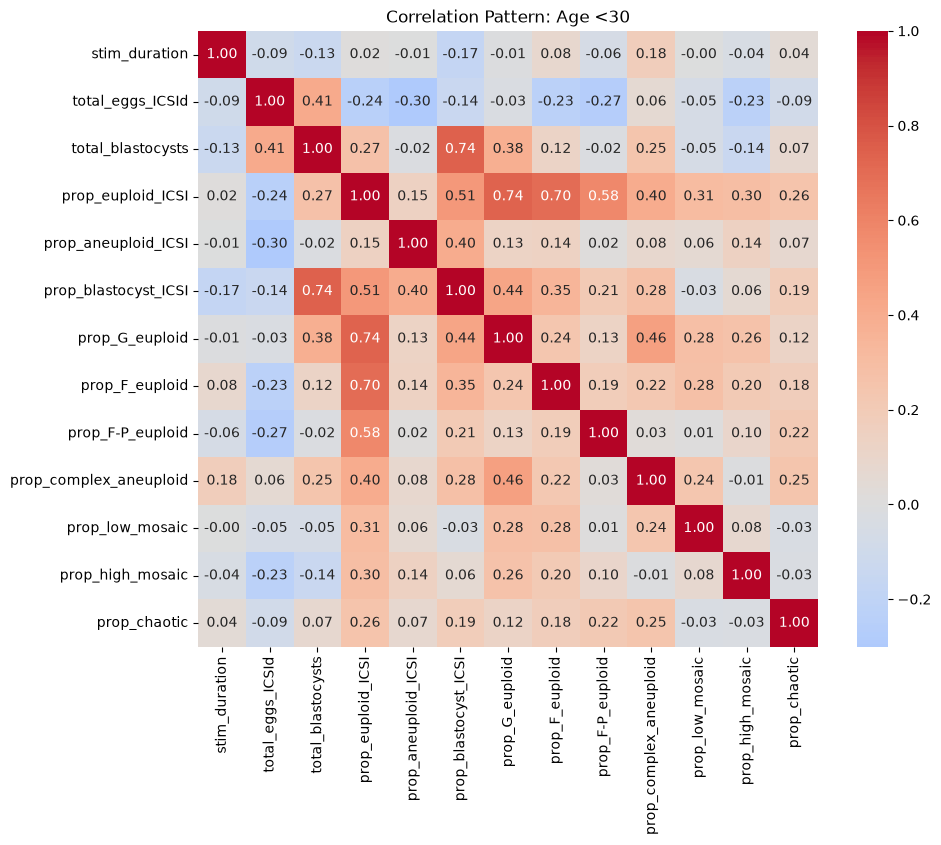

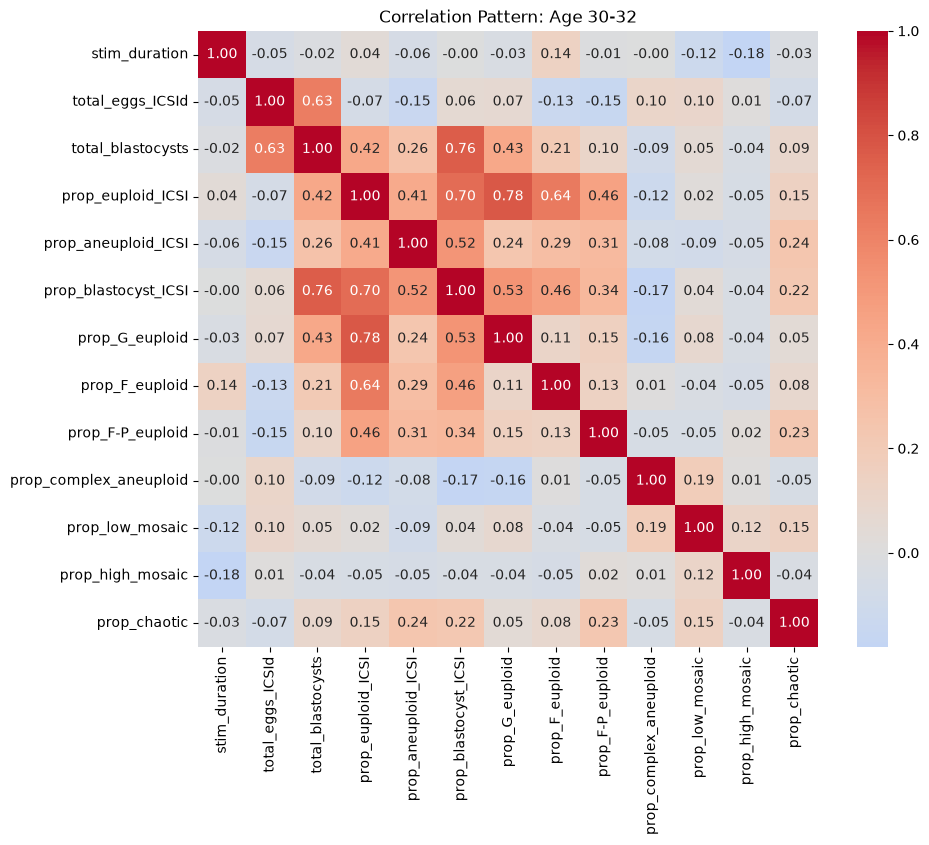

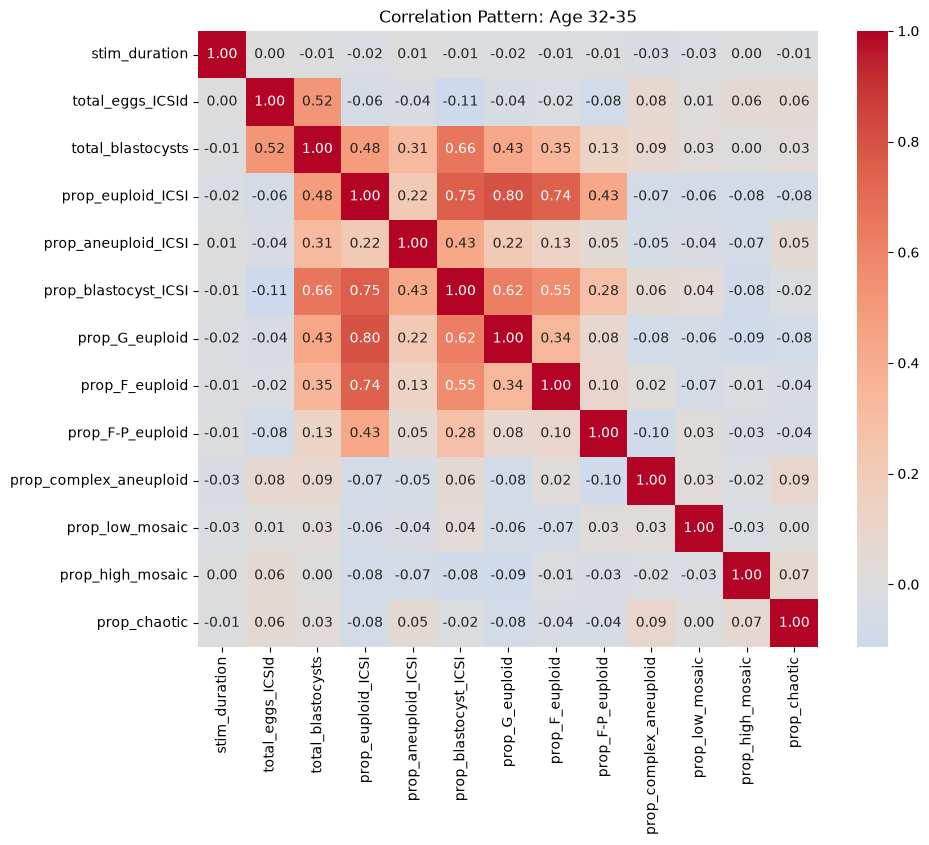

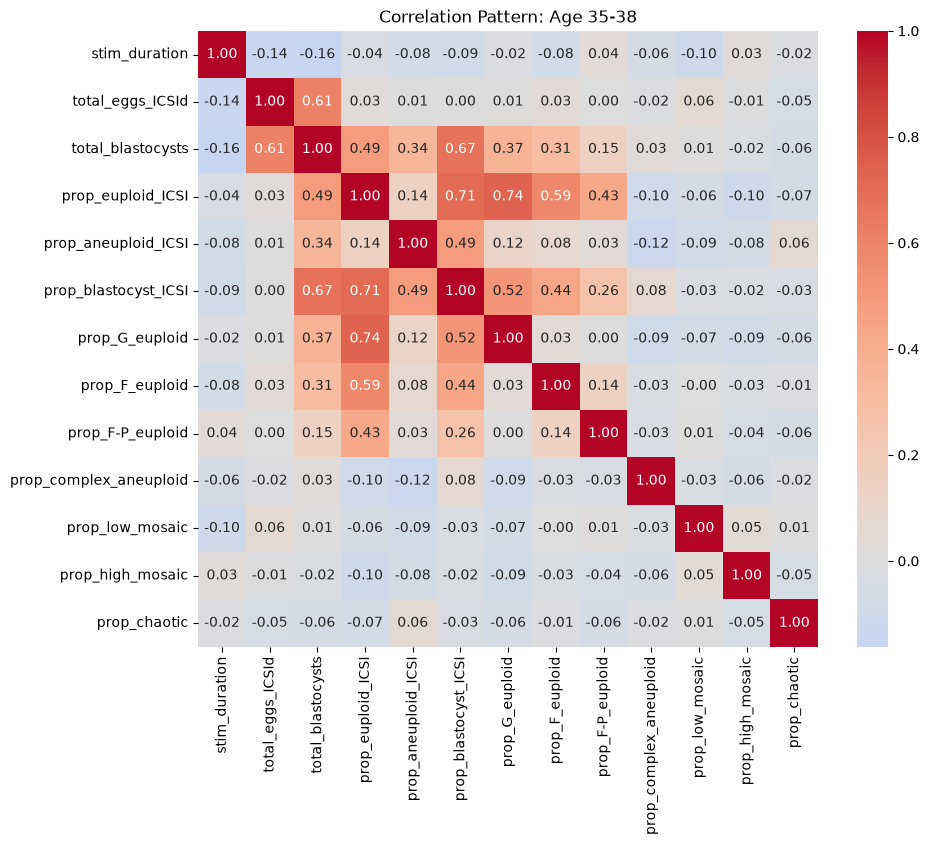

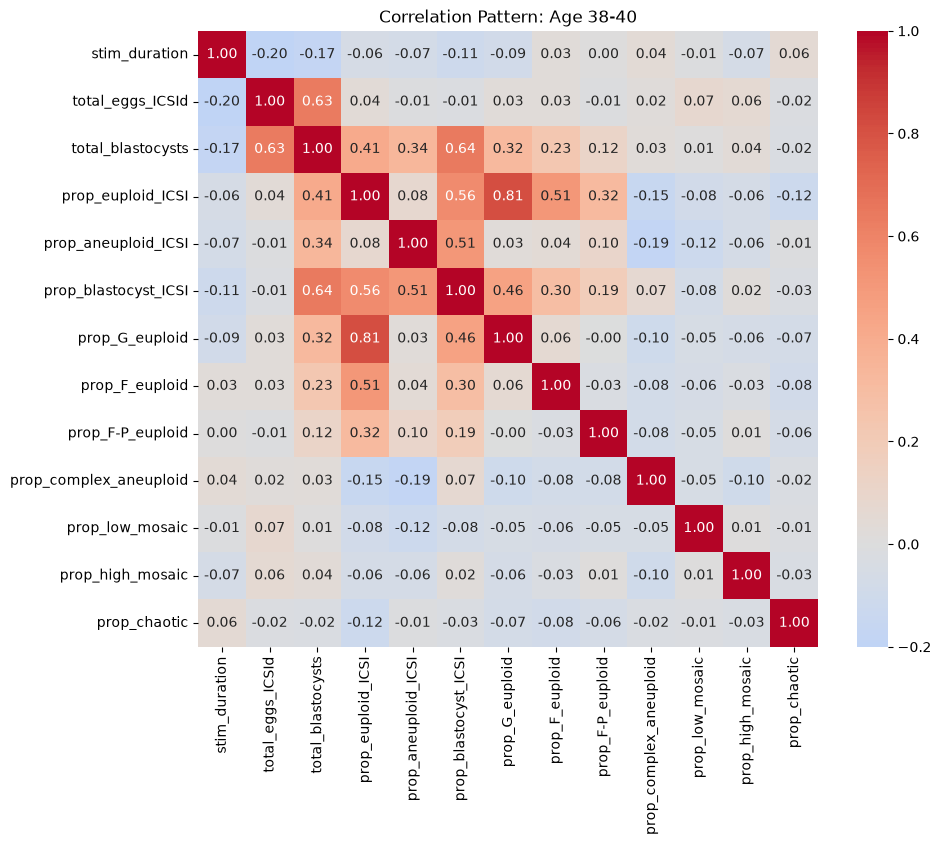

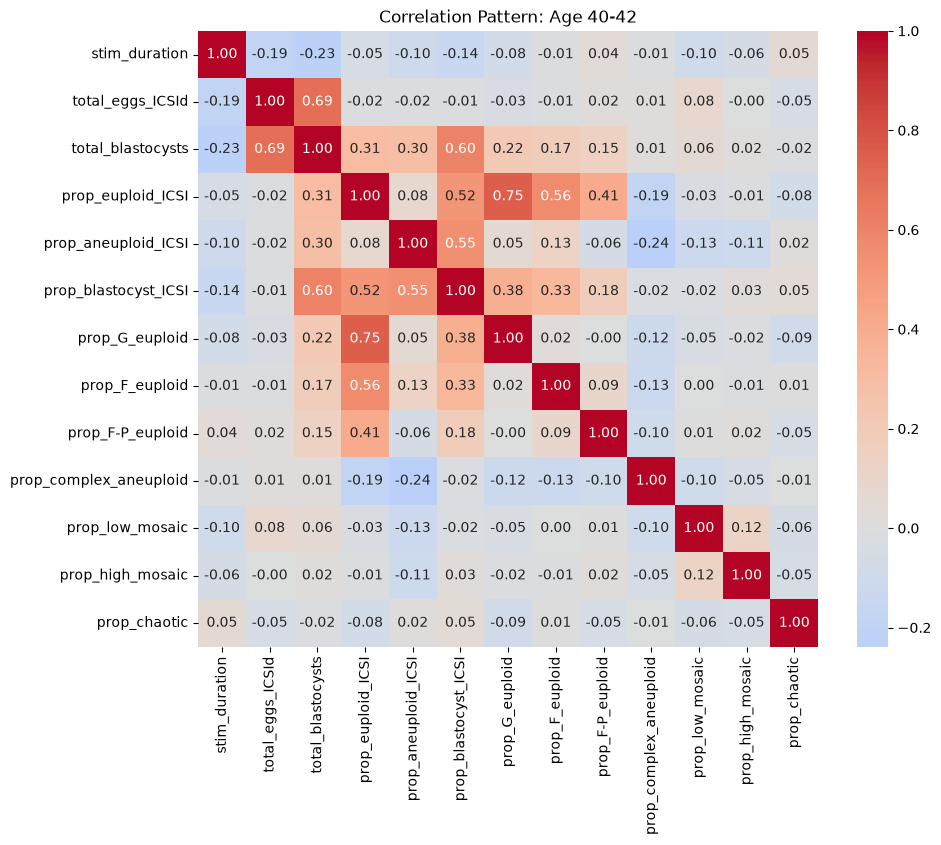

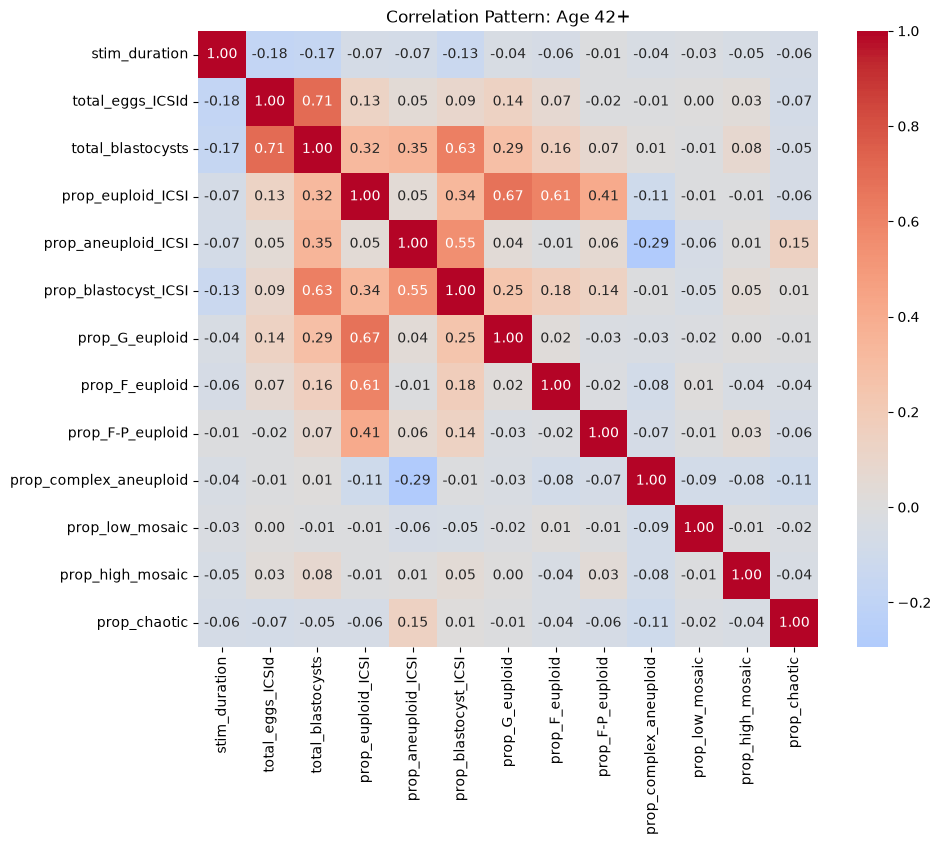

In [443]:
for age in final_df["age_group"].cat.categories:

    subset = final_df[final_df["age_group"] == age]

    if subset.empty:
        continue

    corr = subset[
        [
            "stim_duration",
            "total_eggs_ICSId",
            "total_blastocysts",
            "prop_euploid_ICSI",
            "prop_aneuploid_ICSI",
            "prop_blastocyst_ICSI",
            "prop_G_euploid",
            "prop_F_euploid",
            "prop_F-P_euploid",
            "prop_complex_aneuploid",
            "prop_low_mosaic",
            "prop_high_mosaic",
            "prop_chaotic"
        ]
    ].corr()

    plt.figure(figsize=(10,8))
    sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
    plt.title(f"Correlation Pattern: Age {age}")
    plt.show()


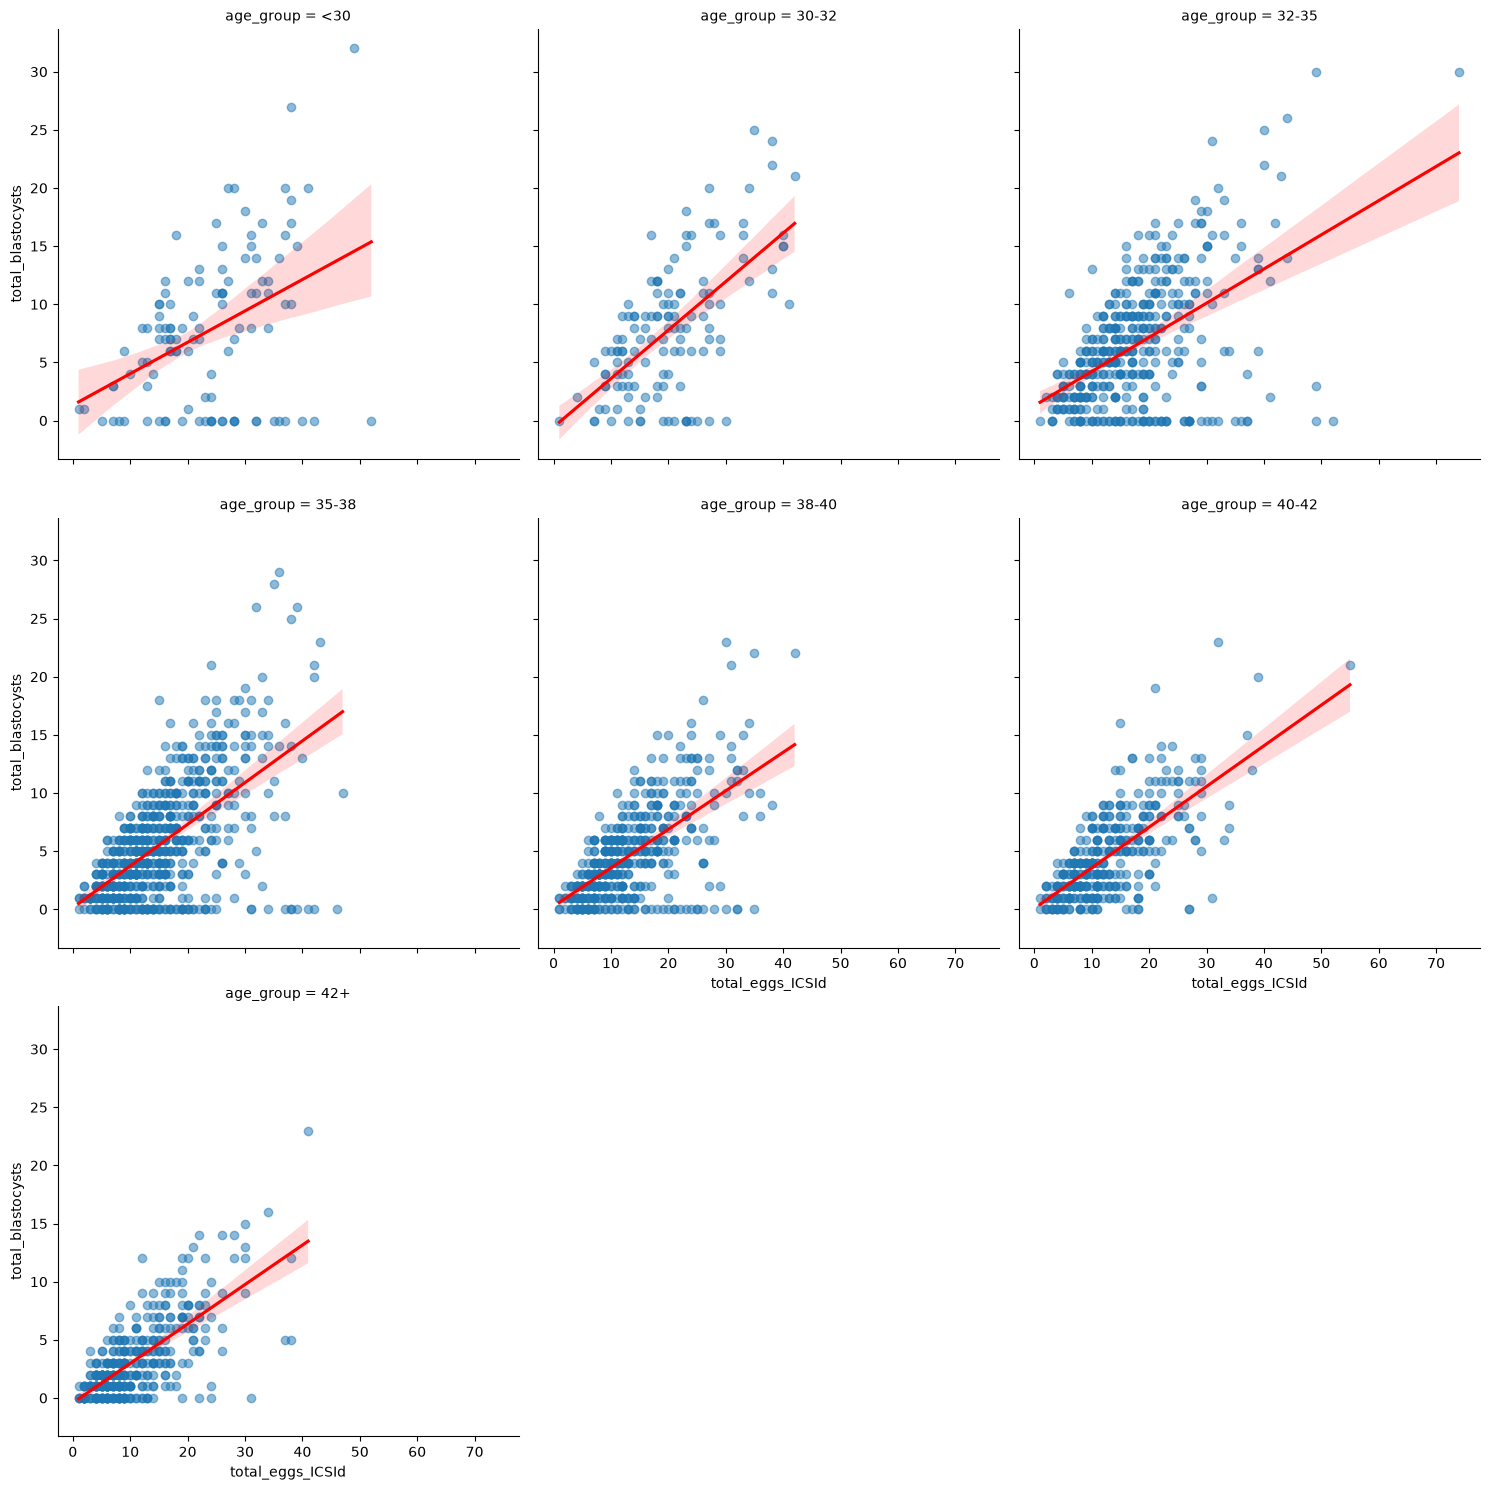

In [444]:
sns.lmplot(
    data=final_df,
    x="total_eggs_ICSId",
    y="total_blastocysts",
    col="age_group",
    col_wrap=3,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)


In [445]:
high_icsi = final_df[final_df["total_eggs_ICSId"] > 50]

display(high_icsi)


,cycleid,stim_start,retrieval_date,trigger_date,patid,total_day5_G,total_day5_F,total_day5_F-P,total_day5_P,total_day6_G,total_day6_F,total_day6_F-P,total_day6_P,total_day7_G,total_day7_F,total_day7_F-P,total_day7_P,total_day_5_euploid,total_day_5_aneuploid,total_day_6_euploid,total_day_6_aneuploid,total_day_7_euploid,total_day_7_aneuploid,total_day5_euploid_AAG,total_day5_aneuploid_AAG,total_day5_euploid_ABG,total_day5_aneuploid_ABG,total_day5_euploid_BAG,total_day5_aneuploid_BAG,total_day5_euploid_BBF,total_day5_aneuploid_BBF,total_day5_euploid_ACF,total_day5_aneuploid_ACF,total_day5_euploid_CAF,total_day5_aneuploid_CAF,total_day5_euploid_BCF-P,total_day5_aneuploid_BCF-P,total_day5_euploid_CBF-P,total_day5_aneuploid_CBF-P,total_day5_euploid_BBF-P,total_day5_aneuploid_BBF-P,total_day5_euploid_CCP,total_day5_aneuploid_CCP,total_day5_euploid_BCP,total_day5_aneuploid_BCP,total_day5_euploid_CBP,total_day5_aneuploid_CBP,total_day5_euploid_XXP,total_day5_aneuploid_XXP,total_day5_euploid_XXF,total_day5_aneuploid_XXF,total_day6_euploid_AAG,total_day6_aneuploid_AAG,total_day6_euploid_ABG,total_day6_aneuploid_ABG,total_day6_euploid_BAG,total_day6_aneuploid_BAG,total_day6_euploid_BBF,total_day6_aneuploid_BBF,total_day6_euploid_ACF,total_day6_aneuploid_ACF,total_day6_euploid_CAF,total_day6_aneuploid_CAF,total_day6_euploid_BCF-P,total_day6_aneuploid_BCF-P,total_day6_euploid_CBF-P,total_day6_aneuploid_CBF-P,total_day6_euploid_BBF-P,total_day6_aneuploid_BBF-P,total_day6_euploid_CCP,total_day6_aneuploid_CCP,total_day6_euploid_BCP,total_day6_aneuploid_BCP,total_day6_euploid_CBP,total_day6_aneuploid_CBP,total_day6_euploid_XXP,total_day6_aneuploid_XXP,total_day6_euploid_XXF,total_day6_aneuploid_XXF,total_day7_euploid_AAG,total_day7_aneuploid_AAG,total_day7_euploid_ABG,total_day7_aneuploid_ABG,total_day7_euploid_BAG,total_day7_aneuploid_BAG,total_day7_euploid_BBF,total_day7_aneuploid_BBF,total_day7_euploid_ACF,total_day7_aneuploid_ACF,total_day7_euploid_CAF,total_day7_aneuploid_CAF,total_day7_euploid_BCF-P,total_day7_aneuploid_BCF-P,total_day7_euploid_CBF-P,total_day7_aneuploid_CBF-P,total_day7_euploid_BBF-P,total_day7_aneuploid_BBF-P,total_day7_euploid_CCP,total_day7_aneuploid_CCP,total_day7_euploid_BCP,total_day7_aneuploid_BCP,total_day7_euploid_CBP,total_day7_aneuploid_CBP,total_day7_euploid_XXP,total_day7_aneuploid_XXP,total_day7_euploid_XXF,total_day7_aneuploid_XXF,total_complex_aneuploid,total_low_mosaic,total_high_mosaic,total_chaotic,total_euploid,total_aneuploid,total_untested,total_blastocysts,total_eggs_ICSId,cycle_type,retrieved,retrievedby,oocytes_retrieved,denuding_performed,denuding_performedby,retrievedtech,labassistant,needle_type,patient_id,account,dob,age_at_stim,stim_duration,prop_euploid_ICSI,prop_blastocyst_ICSI,prop_G_euploid,prop_F_euploid,prop_F-P_euploid,prop_complex_aneuploid,prop_low_mosaic,prop_high_mosaic,prop_chaotic,age_group,needle_type_cleaned,prop_aneuploid_ICSI
992,726ee588-3d8c-4d55-bdb8-1b1cf06520ec,2022-03-20,2022-03-31 07:08:00,2022-03-29 07:08:00,26771.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,52.0,IVF,2022-03-31 07:08:00,89.0,52.0,2022-03-31 21:13:00-07,287.0,32.0,309.0,cook echotip 16 g,26771.0,3416,1988-05-15,34,11.0,0.000000,0.000000,0.000000,0.000000,0.0,NaN,NaN,NaN,NaN,32-35,single lumen,0.000000
2109,75fb7014-dc98-4bc3-9caa-c8eb67e2fc63,2024-10-02,2024-10-12 00:00:00,2024-10-10 00:00:00,66838.0,2.0,3.0,3.0,0.0,0.0,4.0,4.0,0.0,0.0,1.0,0.0,4.0,2.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0

In [446]:
# list unique needle_type values
# Make needle_type lowercase and remove extra spaces
final_df["needle_type"] = (
    final_df["needle_type"]
    .astype("string")
    .str.strip()
    .str.lower()
)

# Count each value (including missing values)
display(final_df["needle_type"].value_counts(dropna=False))



needle_type
double lumen needle                        1328
cook echotip 16 g                          1311
cook echotip 16 g, double lumen needle       28
double lumen needle, cook echotip 16 g       26
<NA>                                         22
single lumen                                 14
double lumen                                  3
single                                        3
cook echotip 16 g,, double lumen needle       2
double lumen needle and single lumen          1
cook echotip 16 g, double                     1
cook echotip 16 g, double lumen               1
single lumen needle                           1
Name: count, dtype: Int64

In [ ]:
# Normalize first
final_df["needle_type"] = (
    final_df["needle_type"]
    .astype("string")
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.lower()
)

"""
def clean_needle_type(x):
    if pd.isna(x):
        return pd.NA

    if x in [
        "single",
        "single lumen",
        "single lumen needle",
        "cook echotip 16 g"
    ]:
        return "single lumen"

    elif x in [
        "double lumen",
        "double lumen needle"
    ]:
        return "double lumen"

    elif x in [
        "cook echotip 16 g, double lumen",
        "cook echotip 16 g, double",
        "cook echotip 16 g, double lumen needle",
        "double lumen needle and single lumen",
        "cook echotip 16 g,, double lumen needle",
        "cook echotip 16 g, double lumen",
        "cook echotip 16 g, double",
        "double lumen needle, cook echotip 16 g"
    ]:
        return "single and double lumen"

    else:
        return x
"""
#final_df["needle_type_cleaned"] = final_df["needle_type"].apply(clean_needle_type)
final_df["needle_type_cleaned"] = (
    final_df["needle_type"]
    .apply(helper_functions.clean_needle_type)
)

display(final_df["needle_type_cleaned"].value_counts(dropna=False))


needle_type_cleaned
double lumen               1331
single lumen               1329
single and double lumen      59
NaN                          22
Name: count, dtype: int64

In [ ]:
# save as csv
final_df.to_csv("../data/lab_data_pipelined.csv", index=False)

## 9. PCA

look at patterns of variation in the data

### PCA with selected variables

In [453]:
# Variables to include in PCA
pca_vars = [
    #"age_at_stim",
    "stim_duration",
    "total_eggs_ICSId",
    "total_blastocysts",
    "prop_euploid_ICSI",
    #"prop_aneuploid_ICSI",
    "prop_blastocyst_ICSI",
    "prop_G_euploid",
    "prop_F_euploid",
    "prop_F-P_euploid",
    "prop_complex_aneuploid",
    "prop_low_mosaic",
    "prop_high_mosaic",
    "prop_chaotic"
]

# Keep only rows with complete PCA variables
pca_df = final_df[pca_vars].dropna().copy()

# Standardize variables (important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_df)

# Run PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Create PCA dataframe
pca_results = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(X_pca.shape[1])],
    index=pca_df.index
)

display(pca_results.head())


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
803,-0.281873,-0.995846,1.893880,-0.514012,-1.189585,0.118677,1.683290,1.510034,0.781926,-0.221556,-0.106037,-0.010931
2907,1.783989,-1.477959,-0.305598,-0.168474,-0.229808,-0.293932,-0.644949,-1.534751,-1.235720,-0.653408,0.012975,-0.006114
3034,-0.185883,-1.173234,-0.751105,-0.636203,0.924978,-0.839217,0.491981,-0.542606,0.805208,-0.264349,0.123724,-0.004289
3258,2.865237,-0.142145,-0.223707,0.483068,-0.717070,0.998227,-0.765136,0.307898,-0.750980,0.369408,0.055989,-0.017217
3453,-0.986565,0.282931,-1.225357,0.004141,0.071345,-0.901819,-1.564700,1.103425,-0.300011,-0.059725,-0.053047,-0.010152


In [454]:
explained_variance = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Variance Explained": pca.explained_variance_ratio_,
    "Cumulative Variance": pca.explained_variance_ratio_.cumsum()
})

display(explained_variance)

#first 2 PCs only explain 37.4% of variation. Not one dominant underlying axis from the variable I included.

,PC,Variance Explained,Cumulative Variance
0,PC1,0.250280,0.250280
1,PC2,0.130957,0.381237
2,PC3,0.096000,0.477236
3,PC4,0.083823,0.561060
4,PC5,0.081439,0.642499
5,PC6,0.080267,0.722766
6,PC7,0.078032,0.800798
7,PC8,0.074872,0.875670
8,PC9,0.069888,0.945559
9,PC10,0.048980,0.994538


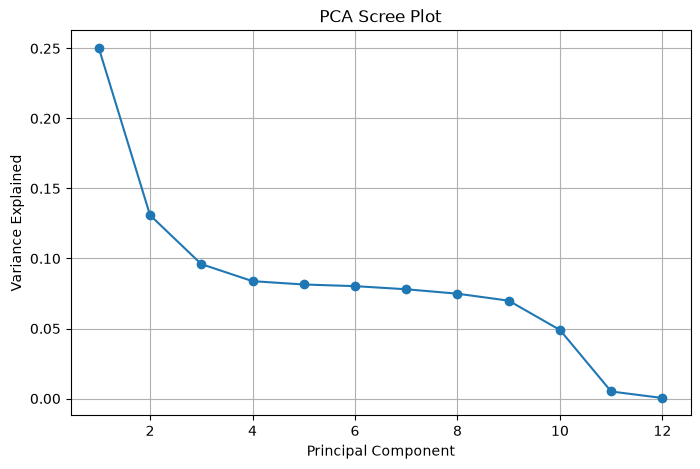

In [455]:
plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_)+1),
    pca.explained_variance_ratio_,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.title("PCA Scree Plot")
plt.grid(True)
plt.show()


In [456]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(pca.components_))],
    index=pca_vars
)

display(loadings.sort_values("PC1", ascending=False))


# PC1: overall reproductive outcome quality
    # High PC1 = younger patients with more embryos, more blastocysts, higher euploid yield; Low PC1 = older patients with lower embryo yield and more abnormal embryos

# PC2: egg quantity vs embryo efficiency
    # This could reflect ovarian stimulation response: high responders produce many embryos but not necessarily better-quality embryos; low responders may have fewer but proportionally better embryos

# PC3: abnormal embryo phenotype
    # Older age → more complex aneuploid embryos

# PC4 / PC5: unusual embryo genetics patterns


# PC1: overall embryo success

# PC2: egg quantity vs embryo efficiency

# PC3: 

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
prop_euploid_ICSI,0.519280,-0.273039,-0.033274,0.001117,-0.027381,-0.015539,-0.035114,-0.034670,0.013989,-0.334318,0.002634,0.734365
prop_blastocyst_ICSI,0.421212,-0.118469,0.210979,0.083977,-0.095416,0.068713,0.182540,0.191382,-0.190504,0.674920,-0.425888,-0.004389
total_blastocysts,0.406306,0.496463,0.165886,-0.034731,0.142314,-0.013668,0.042814,0.072875,-0.087048,0.191502,0.698483,0.001689
prop_G_euploid,0.399376,-0.158959,0.088511,0.093506,-0.217804,0.205474,-0.440700,-0.151263,-0.369137,-0.315350,-0.002832,-0.506144
prop_F_euploid,0.341324,-0.175964,-0.015608,0.038518,0.049025,0.036730,0.209648,0.327104,0.723801,-0.178206,0.015864,-0.374445
total_eggs_ICSId,0.196079,0.682820,0.032286,-0.110924,0.248527,-0.077745,-0.066459,-0.044814,0.049717,-0.273732,-0.574726,-0.004318
prop_F-P_euploid,0.195461,-0.217241,-0.256738,-0.246371,0.273412,-0.503883,0.472061,-0.285260,-0.289793,-0.082102,0.011701,-0.253503
prop_low_mosaic,0.027363,0.143595,-0.488669,0.193455,-0.336076,-0.456379,-0.166522,0.569528,-0.168558,-0.025706,0.004067,-0.000164
prop_high_mosaic,0.012227,0.096654,-0.508693,-0.017012,0.065779,0.690006,0.385377,0.170626,-0.247003,-0.111203,0.002532,0.001874
stim_duration,-0.070084,-0.253010,0.075019,-0.298515,0.658328,0.035813,-0.354775,0.494402,-0.176869,0.008466,0.000313,-0.001757


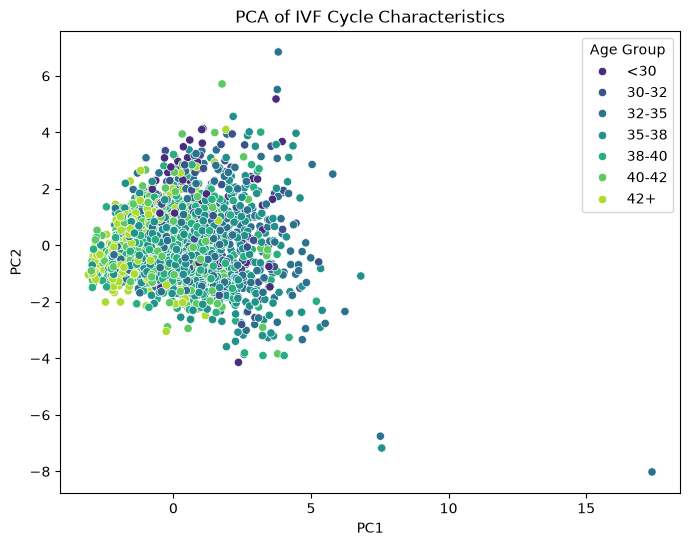

In [457]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_results["PC1"],
    y=pca_results["PC2"],
    hue=final_df.loc[pca_df.index, "age_group"],
    alpha=0.8,
    palette="viridis"
)

plt.title("PCA of IVF Cycle Characteristics")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Age Group")
plt.show()


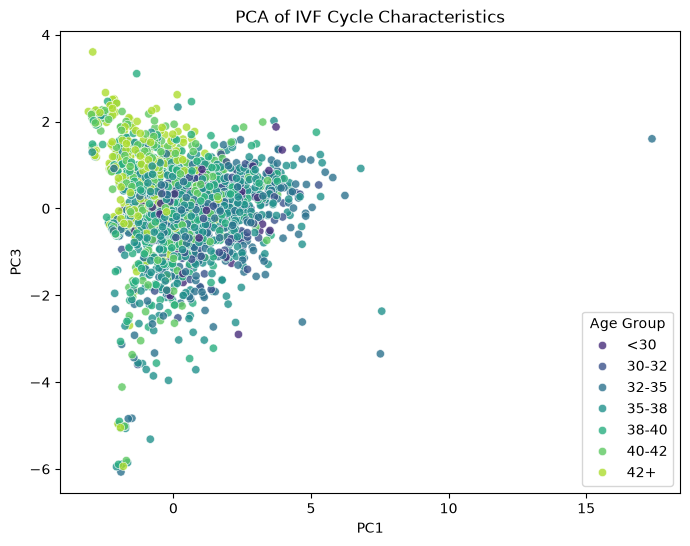

In [463]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_results["PC1"],
    y=pca_results["PC3"],
    hue=final_df.loc[pca_df.index, "age_group"],
    alpha=0.8,
    palette="viridis"
)

plt.title("PCA of IVF Cycle Characteristics")
plt.xlabel("PC1")
plt.ylabel("PC3")
plt.legend(title="Age Group")
plt.show()

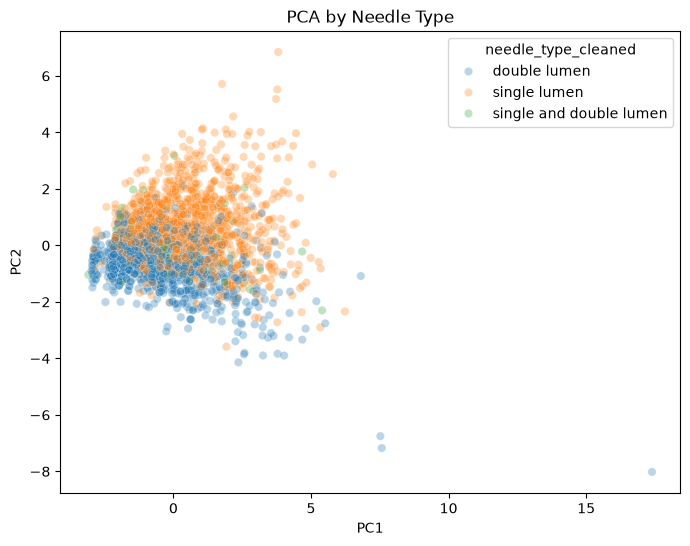

In [459]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_results["PC1"],
    y=pca_results["PC2"],
    hue=final_df.loc[pca_df.index,"needle_type_cleaned"],
    alpha=0.3
)

plt.title("PCA by Needle Type")
plt.show()


In [460]:
# does age drive PC1

from scipy.stats import pearsonr

corr, p = pearsonr(
    final_df.loc[pca_df.index, "age_at_stim"].astype(float),
    pca_results["PC1"]
)

print(f"Correlation age vs PC1: {corr:.3f}")
print(f"P-value: {p:.3e}")


Correlation age vs PC1: -0.400
P-value: 2.983e-91


### PCA with all variables and split by needle type

In [433]:
def run_pca(df, variables, title="PCA"):

    X = df[variables].copy()

    # remove rows with missing values
    X = X.dropna()

    # remove columns with no variation
    X = X.loc[:, X.nunique() > 1]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA()
    scores = pca.fit_transform(X_scaled)

    pca_scores = pd.DataFrame(
        scores,
        columns=[f"PC{i+1}" for i in range(scores.shape[1])],
        index=X.index
    )

    loadings = pd.DataFrame(
        pca.components_.T,
        index=X.columns,
        columns=[f"PC{i+1}" for i in range(pca.n_components_)]
    )

    variance = pd.DataFrame({
        "PC":[f"PC{i+1}" for i in range(pca.n_components_)],
        "Variance Explained":pca.explained_variance_ratio_,
        "Cumulative":pca.explained_variance_ratio_.cumsum()
    })

    display(variance.head(10))

    print("\nTop PC1 variables")
    display(loadings["PC1"].abs().sort_values(ascending=False).head(20))

    print("\nTop PC2 variables")
    display(loadings["PC2"].abs().sort_values(ascending=False).head(20))

    plt.figure(figsize=(8,6))

    sns.scatterplot(
        x=pca_scores["PC1"],
        y=pca_scores["PC2"],
        hue=df.loc[X.index, "age_at_stim"].astype(float),
        palette="viridis",
        alpha=.8
    )

    plt.title(title)
    plt.xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)")
    plt.ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)")

    plt.tight_layout()
    plt.show()

    return pca_scores, loadings, variance


,PC,Variance Explained,Cumulative
0,PC1,0.336890,0.336890
1,PC2,0.139489,0.476379
2,PC3,0.114721,0.591100
3,PC4,0.074534,0.665633
4,PC5,0.073810,0.739443
5,PC6,0.066700,0.806143
6,PC7,0.060570,0.866713
7,PC8,0.053382,0.920095
8,PC9,0.042715,0.962810
9,PC10,0.020708,0.983518



Top PC1 variables


total_blastocysts          0.447948
total_euploid              0.394427
total_eggs_ICSId           0.341602
oocytes_retrieved          0.341476
prop_blastocyst_ICSI       0.289426
prop_euploid_ICSI          0.272566
total_aneuploid            0.269557
total_low_mosaic           0.229978
total_high_mosaic          0.207462
age_at_stim                0.179116
total_complex_aneuploid    0.177239
stim_duration              0.101505
total_chaotic              0.100106
Name: PC1, dtype: float64


Top PC2 variables


prop_blastocyst_ICSI       0.500370
oocytes_retrieved          0.487055
total_eggs_ICSId           0.486770
prop_euploid_ICSI          0.405184
age_at_stim                0.228780
total_euploid              0.145065
total_complex_aneuploid    0.102876
total_chaotic              0.100992
total_aneuploid            0.094018
stim_duration              0.066195
total_blastocysts          0.052197
total_high_mosaic          0.032497
total_low_mosaic           0.010901
Name: PC2, dtype: float64

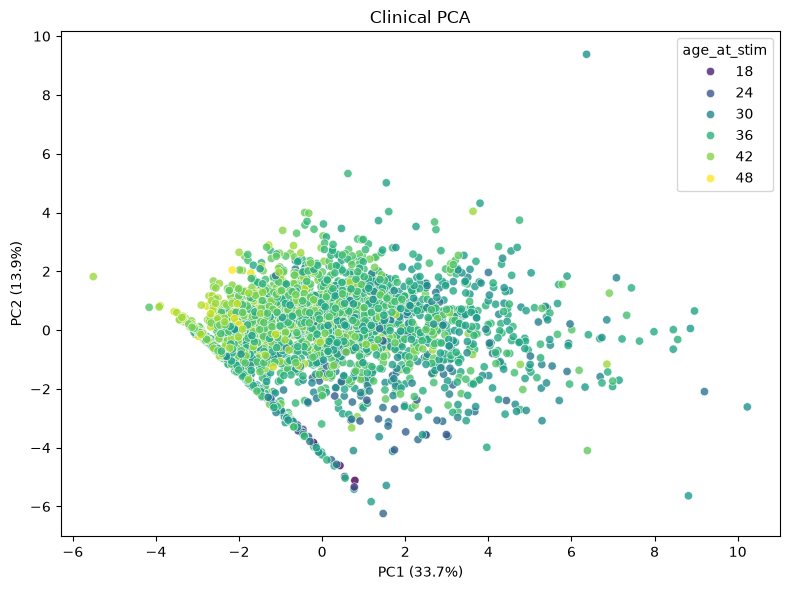

In [434]:
clinical_vars = [

    "age_at_stim",
    "stim_duration",

    "oocytes_retrieved",
    "total_eggs_ICSId",

    "total_blastocysts",

    "total_euploid",
    "total_aneuploid",
    "total_complex_aneuploid",
    "total_low_mosaic",
    "total_high_mosaic",
    "total_chaotic",

    "prop_blastocyst_ICSI",
    "prop_euploid_ICSI"
]

clinical_scores, clinical_loadings, clinical_variance = run_pca(
    final_df,
    clinical_vars,
    "Clinical PCA"
)



,PC,Variance Explained,Cumulative
0,PC1,0.247192,0.247192
1,PC2,0.128824,0.376017
2,PC3,0.116898,0.492915
3,PC4,0.098616,0.591531
4,PC5,0.092552,0.684083
5,PC6,0.073629,0.757712
6,PC7,0.060135,0.817847
7,PC8,0.053369,0.871216
8,PC9,0.037564,0.908780
9,PC10,0.026131,0.934911



Top PC1 variables


total_euploid              0.443916
prop_euploid_ICSI          0.424356
total_blastocysts          0.382424
prop_blastocyst_ICSI       0.355679
prop_G_euploid             0.329668
prop_F_euploid             0.276363
total_low_mosaic           0.201581
total_aneuploid            0.193853
total_high_mosaic          0.182335
prop_F-P_euploid           0.155016
prop_complex_aneuploid     0.117852
prop_low_mosaic            0.067055
total_complex_aneuploid    0.066748
prop_high_mosaic           0.053180
total_chaotic              0.044920
prop_chaotic               0.043257
Name: PC1, dtype: float64


Top PC2 variables


total_complex_aneuploid    0.494744
total_chaotic              0.449698
prop_complex_aneuploid     0.365641
prop_chaotic               0.333735
total_blastocysts          0.252536
total_aneuploid            0.237257
prop_euploid_ICSI          0.231449
total_low_mosaic           0.187288
prop_F-P_euploid           0.160276
prop_G_euploid             0.156293
prop_F_euploid             0.139194
prop_blastocyst_ICSI       0.116056
prop_low_mosaic            0.083756
total_high_mosaic          0.079275
total_euploid              0.054040
prop_high_mosaic           0.006100
Name: PC2, dtype: float64

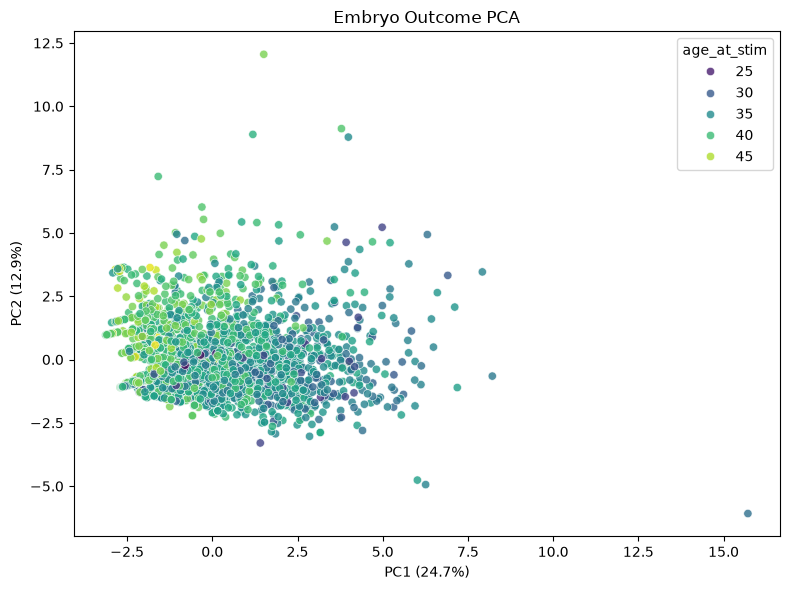

In [435]:
outcome_vars = [

    "prop_euploid_ICSI",
    "prop_blastocyst_ICSI",

    "prop_G_euploid",
    "prop_F_euploid",
    "prop_F-P_euploid",

    "prop_complex_aneuploid",
    "prop_low_mosaic",
    "prop_high_mosaic",
    "prop_chaotic",

    "total_euploid",
    "total_aneuploid",
    "total_complex_aneuploid",
    "total_low_mosaic",
    "total_high_mosaic",
    "total_chaotic",

    "total_blastocysts"
]

outcome_scores, outcome_loadings, outcome_variance = run_pca(
    final_df,
    outcome_vars,
    "Embryo Outcome PCA"
)


,PC,Variance Explained,Cumulative
0,PC1,0.040832,0.040832
1,PC2,0.029685,0.070517
2,PC3,0.026981,0.097498
3,PC4,0.023956,0.121455
4,PC5,0.022184,0.143639
5,PC6,0.021210,0.164849
6,PC7,0.020380,0.185229
7,PC8,0.019853,0.205082
8,PC9,0.019455,0.224537
9,PC10,0.018831,0.243368



Top PC1 variables


total_day5_euploid_ABG        0.348234
total_day5_euploid_AAG        0.308456
total_day5_euploid_BBF        0.306575
total_day5_aneuploid_ABG      0.296640
total_day5_aneuploid_BBF      0.286683
total_day5_euploid_BAG        0.238411
total_day6_euploid_BBF        0.224208
total_day5_aneuploid_AAG      0.195422
total_day6_euploid_ABG        0.194516
total_day5_euploid_BCF-P      0.182888
total_day6_aneuploid_BCF-P    0.182350
total_day6_aneuploid_BBF      0.181128
total_day5_aneuploid_BCF-P    0.177288
total_day5_aneuploid_ACF      0.159062
total_day5_euploid_ACF        0.154748
total_day6_euploid_BCF-P      0.154535
total_day5_aneuploid_BAG      0.130684
total_day6_euploid_BAG        0.126332
total_day6_euploid_AAG        0.122982
total_day6_aneuploid_ABG      0.112109
Name: PC1, dtype: float64


Top PC2 variables


total_day6_euploid_ABG        0.333375
total_day7_euploid_BBF        0.263815
total_day5_aneuploid_BBF      0.243362
total_day5_aneuploid_BCP      0.240298
total_day6_euploid_BBF        0.234618
total_day6_euploid_AAG        0.224613
total_day7_euploid_ACF        0.209332
total_day6_euploid_BCF-P      0.208708
total_day6_aneuploid_ABG      0.204117
total_day5_aneuploid_ABG      0.192883
total_day6_euploid_BAG        0.181372
total_day5_aneuploid_ACF      0.174121
total_day6_aneuploid_BCF-P    0.173646
total_day7_aneuploid_ABG      0.172828
total_day5_aneuploid_BAG      0.166082
total_day5_euploid_BCP        0.160718
total_day5_aneuploid_BCF-P    0.154353
total_day6_aneuploid_BBF      0.153306
total_day6_aneuploid_BCP      0.139893
total_day7_aneuploid_BCF-P    0.135015
Name: PC2, dtype: float64

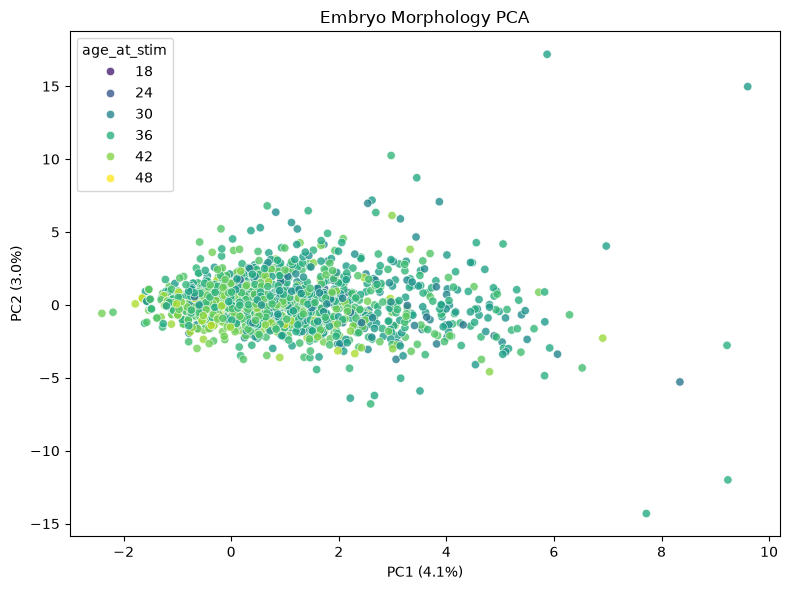

In [438]:
morphology_vars = [

    c for c in final_df.columns

    if (
        c.startswith("total_day5_")
        or c.startswith("total_day6_")
        or c.startswith("total_day7_")
    )

    and (
        "euploid_" in c
        or "aneuploid_" in c
    )
]

morph_scores, morph_loadings, morph_variance = run_pca(
    final_df,
    morphology_vars,
    "Embryo Morphology PCA"
)


double lumen


,PC,Variance Explained,Cumulative
0,PC1,0.311662,0.311662
1,PC2,0.139423,0.451085
2,PC3,0.117714,0.568799
3,PC4,0.079097,0.647896
4,PC5,0.076993,0.724888
5,PC6,0.073398,0.798286
6,PC7,0.063699,0.861985
7,PC8,0.055937,0.917922
8,PC9,0.048626,0.966548
9,PC10,0.018941,0.985489



Top PC1 variables


total_blastocysts          0.467735
total_euploid              0.399405
total_eggs_ICSId           0.326542
oocytes_retrieved          0.325921
prop_blastocyst_ICSI       0.322418
prop_euploid_ICSI          0.296777
total_aneuploid            0.268141
total_complex_aneuploid    0.200609
total_low_mosaic           0.193457
total_high_mosaic          0.167915
age_at_stim                0.145107
total_chaotic              0.095150
stim_duration              0.094558
Name: PC1, dtype: float64


Top PC2 variables


oocytes_retrieved          0.529356
total_eggs_ICSId           0.528749
prop_euploid_ICSI          0.438450
prop_blastocyst_ICSI       0.434693
total_euploid              0.202344
total_complex_aneuploid    0.084045
stim_duration              0.082465
total_blastocysts          0.049334
total_chaotic              0.030148
age_at_stim                0.022533
total_low_mosaic           0.016553
total_high_mosaic          0.008899
total_aneuploid            0.000099
Name: PC2, dtype: float64

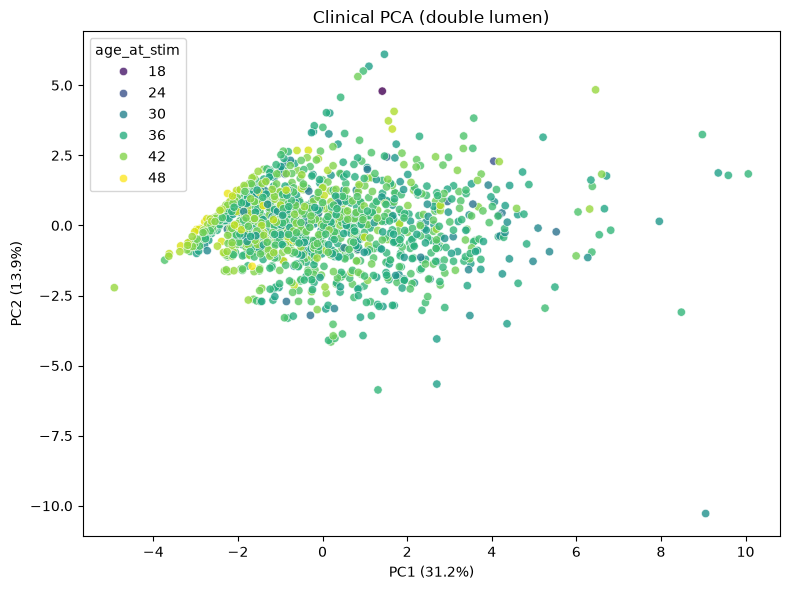

single and double lumen


,PC,Variance Explained,Cumulative
0,PC1,0.319359,0.319359
1,PC2,0.160393,0.479752
2,PC3,0.119502,0.599254
3,PC4,0.105925,0.705179
4,PC5,0.079278,0.784458
5,PC6,0.068494,0.852952
6,PC7,0.056244,0.909196
7,PC8,0.038610,0.947806
8,PC9,0.031336,0.979142
9,PC10,0.013153,0.992294



Top PC1 variables


total_blastocysts          0.465155
total_euploid              0.418877
prop_blastocyst_ICSI       0.387691
prop_euploid_ICSI          0.359546
total_eggs_ICSId           0.280841
oocytes_retrieved          0.280841
age_at_stim                0.225876
total_aneuploid            0.220884
total_low_mosaic           0.181939
total_chaotic              0.136745
stim_duration              0.096719
total_high_mosaic          0.071712
total_complex_aneuploid    0.068877
Name: PC1, dtype: float64


Top PC2 variables


oocytes_retrieved          0.523084
total_eggs_ICSId           0.523084
prop_euploid_ICSI          0.386957
prop_blastocyst_ICSI       0.341226
total_euploid              0.243123
total_chaotic              0.184582
total_low_mosaic           0.175250
total_high_mosaic          0.136958
age_at_stim                0.128915
stim_duration              0.127249
total_aneuploid            0.098811
total_complex_aneuploid    0.035647
total_blastocysts          0.009979
Name: PC2, dtype: float64

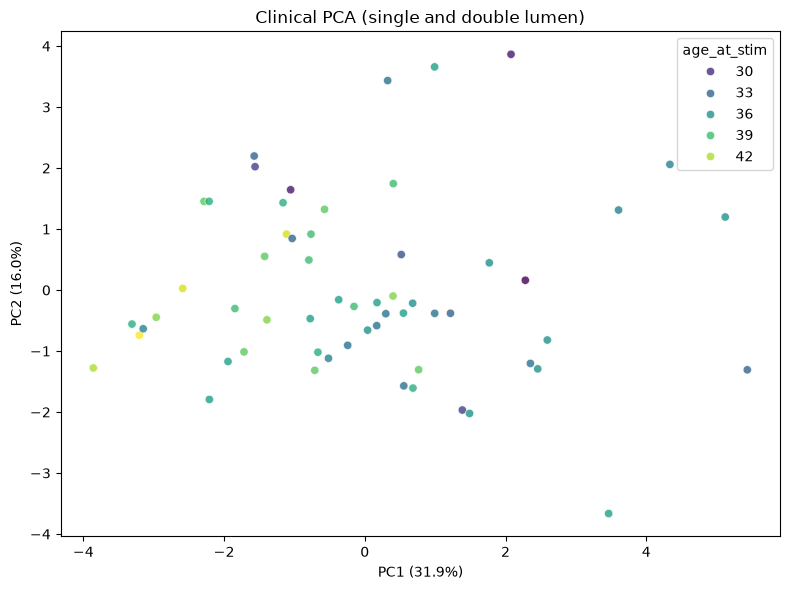

single lumen


,PC,Variance Explained,Cumulative
0,PC1,0.302646,0.302646
1,PC2,0.160834,0.463481
2,PC3,0.123892,0.587373
3,PC4,0.080027,0.667399
4,PC5,0.074039,0.741438
5,PC6,0.068688,0.810126
6,PC7,0.059313,0.869439
7,PC8,0.054183,0.923622
8,PC9,0.045267,0.968889
9,PC10,0.021124,0.990012



Top PC1 variables


total_blastocysts          0.471212
total_euploid              0.418088
prop_blastocyst_ICSI       0.376184
prop_euploid_ICSI          0.328996
total_aneuploid            0.264605
total_eggs_ICSId           0.254638
oocytes_retrieved          0.254593
total_low_mosaic           0.230775
total_high_mosaic          0.209056
total_complex_aneuploid    0.174151
total_chaotic              0.120351
age_at_stim                0.094110
stim_duration              0.055715
Name: PC1, dtype: float64


Top PC2 variables


oocytes_retrieved          0.583058
total_eggs_ICSId           0.582961
prop_blastocyst_ICSI       0.371406
prop_euploid_ICSI          0.345028
age_at_stim                0.196957
total_euploid              0.107646
total_aneuploid            0.067767
total_chaotic              0.059919
total_complex_aneuploid    0.053376
total_high_mosaic          0.037360
total_low_mosaic           0.015989
total_blastocysts          0.012233
stim_duration              0.000229
Name: PC2, dtype: float64

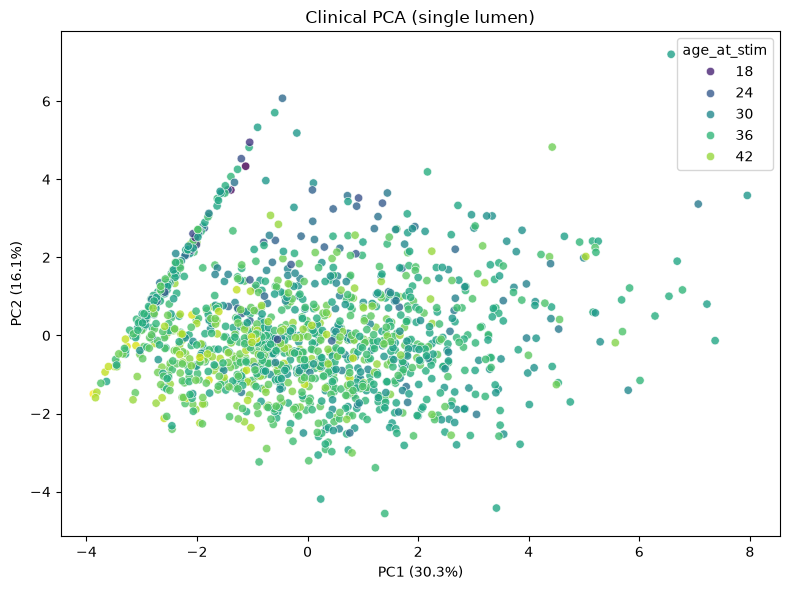

In [439]:
for needle in sorted(final_df["needle_type_cleaned"].dropna().unique()):

    print("="*70)
    print(needle)
    print("="*70)

    subset = final_df[
        final_df["needle_type_cleaned"] == needle
    ]

    run_pca(
        subset,
        clinical_vars,
        f"Clinical PCA ({needle})"
    )


,PC,Variance Explained,Cumulative
0,PC1,0.255094,0.255094
1,PC2,0.141880,0.396973
2,PC3,0.123467,0.520440
3,PC4,0.096265,0.616705
4,PC5,0.094744,0.711449
5,PC6,0.077582,0.789031
6,PC7,0.057120,0.846151
7,PC8,0.052320,0.898471
8,PC9,0.030259,0.928730
9,PC10,0.028297,0.957027



Top PC1 variables


total_euploid              0.444199
prop_euploid_ICSI          0.437152
prop_blastocyst_ICSI       0.379770
total_blastocysts          0.356853
prop_G_euploid             0.355401
prop_F_euploid             0.275943
total_low_mosaic           0.176875
total_high_mosaic          0.168530
prop_F-P_euploid           0.163855
total_aneuploid            0.153009
prop_complex_aneuploid     0.135950
prop_low_mosaic            0.056940
prop_high_mosaic           0.055415
total_chaotic              0.044060
total_complex_aneuploid    0.021732
prop_chaotic               0.020147
Name: PC1, dtype: float64


Top PC2 variables


total_complex_aneuploid    0.488992
total_chaotic              0.488365
prop_chaotic               0.421461
prop_complex_aneuploid     0.387086
total_blastocysts          0.222075
total_aneuploid            0.197994
prop_blastocyst_ICSI       0.166593
prop_euploid_ICSI          0.136988
total_low_mosaic           0.129105
prop_F-P_euploid           0.115723
prop_F_euploid             0.107393
prop_high_mosaic           0.085835
prop_G_euploid             0.072811
total_euploid              0.058584
prop_low_mosaic            0.040809
total_high_mosaic          0.022906
Name: PC2, dtype: float64

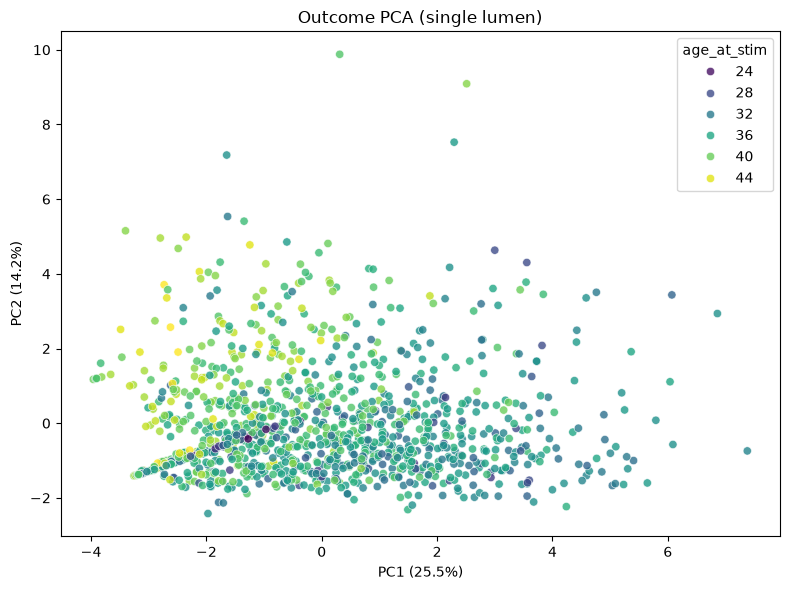

,PC,Variance Explained,Cumulative
0,PC1,0.042465,0.042465
1,PC2,0.036807,0.079272
2,PC3,0.035894,0.115166
3,PC4,0.029489,0.144655
4,PC5,0.027749,0.172404
5,PC6,0.027143,0.199547
6,PC7,0.025110,0.224657
7,PC8,0.024323,0.248980
8,PC9,0.023341,0.272321
9,PC10,0.022958,0.295279



Top PC1 variables


total_day5_euploid_ABG        0.352350
total_day5_aneuploid_ABG      0.339919
total_day5_euploid_AAG        0.321305
total_day5_aneuploid_BBF      0.312201
total_day5_euploid_BBF        0.294199
total_day5_euploid_BAG        0.244288
total_day5_aneuploid_AAG      0.239888
total_day5_aneuploid_BCF-P    0.200904
total_day5_aneuploid_ACF      0.192994
total_day5_euploid_BCF-P      0.178676
total_day5_aneuploid_BAG      0.155632
total_day6_euploid_BBF        0.154681
total_day6_aneuploid_BCF-P    0.149581
total_day5_euploid_ACF        0.142444
total_day6_euploid_ABG        0.142152
total_day6_aneuploid_BBF      0.141571
total_day5_aneuploid_BCP      0.126202
total_day5_euploid_BCP        0.102588
total_day6_euploid_BCF-P      0.101956
total_day6_aneuploid_BAG      0.096135
Name: PC1, dtype: float64


Top PC2 variables


total_day6_euploid_ABG        0.346146
total_day7_euploid_BBF        0.297971
total_day6_euploid_BBF        0.273958
total_day6_euploid_BCF-P      0.234730
total_day6_euploid_AAG        0.227144
total_day7_euploid_ACF        0.214645
total_day5_aneuploid_BCP      0.212978
total_day6_aneuploid_ABG      0.212065
total_day6_euploid_BAG        0.201867
total_day7_aneuploid_ABG      0.190503
total_day5_aneuploid_BBF      0.188931
total_day6_aneuploid_BBF      0.173779
total_day6_aneuploid_BCF-P    0.171517
total_day5_euploid_BCP        0.166839
total_day5_aneuploid_ACF      0.153497
total_day5_aneuploid_ABG      0.153168
total_day6_aneuploid_AAG      0.130918
total_day6_euploid_XXF        0.121176
total_day5_aneuploid_BCF-P    0.119553
total_day7_aneuploid_BBF      0.118366
Name: PC2, dtype: float64

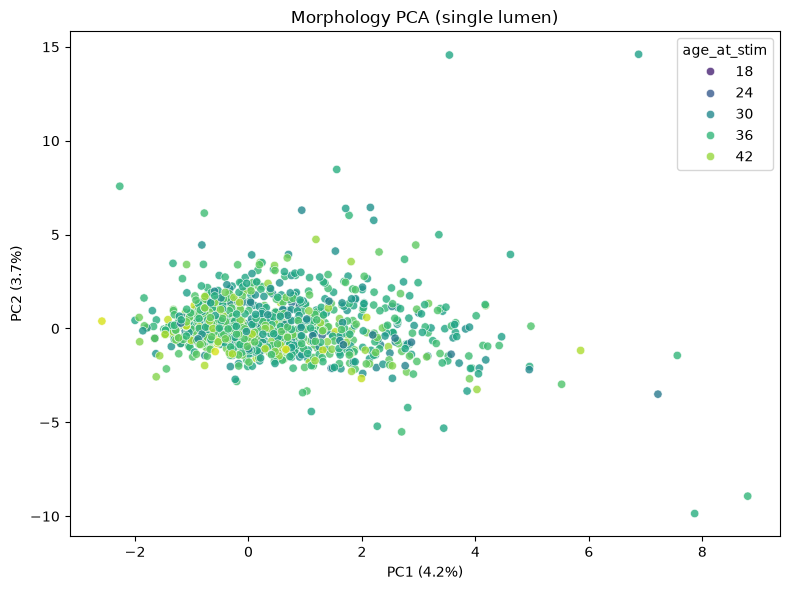

(           PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
 1775 -1.651559 -0.524925 -0.025970 -0.023991 -0.068003 -0.233831  0.377491   
 3258  0.282296  1.220142 -0.431669  0.467162  0.206255 -0.910237 -1.035917   
 3453 -0.985497  0.602588 -0.297096  0.034669 -0.056572 -0.028717 -0.679354   
 2010 -0.482527  1.610013 -0.586172 -0.279128 -0.114970  0.581701 -2.602540   
 648   3.520793 -1.464971  0.502392 -0.441059  0.448659 -1.529118  0.117459   
 ...        ...       ...       ...       ...       ...       ...       ...   
 1446 -1.651559 -0.524925 -0.025970 -0.023991 -0.068003 -0.233831  0.377491   
 1384  1.515329 -2.067985  0.578053 -0.842452  0.143338 -0.666553  1.166404   
 3009  1.178602 -0.684710  0.158746 -0.785572 -0.513768  0.531208  0.183397   
 1653 -1.651559 -0.524925 -0.025970 -0.023991 -0.068003 -0.233831  0.377491   
 1104 -0.036766 -0.162551 -0.161580 -0.136193  0.236575 -1.042614  0.259283   
 
            PC8       PC9      PC10      PC11     

In [440]:
run_pca(subset, outcome_vars, f"Outcome PCA ({needle})")
run_pca(subset, morphology_vars, f"Morphology PCA ({needle})")
